In [167]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

from tabulate import tabulate
from math import pi
import joblib

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier

# **Data validation and preparation**

**Description of dataset features**

| **Feature**            | **Description**                                                                                            |
| ---------------------- | ---------------------------------------------------------------------------------------------------------- |
| **Artist ID**          | Unique identifier of the artist on Spotify.                                                                |
| **Artist name**        | Name of the artist or band.                                                                                |
| **Region**             | Region/country where the track is collected or considered popular.                                         |
| **Track ID**           | Unique identifier of the track on Spotify.                                                                 |
| **Track name**         | Title of the song/track.                                                                                   |
| **Release date**       | The date the track or album was released.                                                                  |
| **Genre**              | Genre associated with the artist or track.                                                                 |
| **Popularity**         | Track popularity rating (0 to 100), calculated by Spotify based on streams, likes, etc.                    |
| **Explicit**           | Indicates whether the track contains explicit content (`True/False`).                                      |
| **Duration**           | Length of the track in milliseconds.                                                                       |
| **Duration (min:sec)** | Duration of the track in (minutes:seconds) format.                                                         |
| **Acousticness**       | Probability that the track is acoustic (from 0.0 to 1.0).                                                  |
| **Danceability**       | How suitable a track is for dancing, based on tempo, rhythm stability, and beat strength (0.0–1.0).        |
| **Energy**             | Intensity and activity level of the track (0.0–1.0).                                                       |
| **Instrumentalness**   | Probability that the track is instrumental (higher values ≈ less vocal content).                           |
| **Key**                | Musical key of the track, represented as integers (0–11) corresponding to C, C#, ..., B.                   |
| **Liveness**           | Probability that the track was performed live (0.0–1.0).                                                   |
| **Loudness**           | Average loudness of the track in decibels (dB). Typically negative values.                                 |
| **Mode**               | Modality of the track: major (1) or minor (0).                                                             |
| **Speechiness**        | Measure of spoken words in a track (0.0–1.0). Higher values indicate more speech-like content (e.g., rap). |
| **Tempo**              | Tempo of the track in beats per minute (BPM).                                                              |
| **Valence**            | Musical positivity of the track (0.0 = sad, 1.0 = happy, cheerful).                                        |

In [168]:
df = pd.read_csv("../data/cleaned_data/spotify_europeVSjapan_analysis.csv") 
df.head()

,Artist ID,Artist name,Region,Track ID,Track name,Release date,Genre,Popularity,Explicit,Duration,...,Danceability,Energy,Instrumentalness,Key,Liveness,Loudness,Mode,Speechiness,Tempo,Valence
0,0MK8l3nURwwQIjafvXoJJt,ASIAN KUNG-FU GENERATION,Japan,5ORPYXJKlpHWIdceavSGrL,遥か彼方,2012-01,j-rock,64.0,False,243346,...,0.308,0.955,0.113,E,0.1660,-3.763,Major,0.1110,174.991,0.237
1,0MK8l3nURwwQIjafvXoJJt,ASIAN KUNG-FU GENERATION,Japan,0WaaPFt4Qy8sVfxKz43bCD,Re:Re:,2004-10,j-rock,59.0,False,228760,...,0.537,0.864,0.123,E,0.1080,-5.049,Major,0.0369,153.035,0.727
2,0MK8l3nURwwQIjafvXoJJt,ASIAN KUNG-FU GENERATION,Japan,052C0m9kD30nZqcPWPPRqm,Haruka Kanata,2012-01,j-rock,59.0,False,243347,...,0.316,0.951,0.189,C#,0.1700,-3.757,Minor,0.1120,174.895,0.255
3,0MK8l3nURwwQIjafvXoJJt,ASIAN KUNG-FU GENERATION,Japan,2sFBiCSUNc3ptKrCR8JABx,ブラッドサーキュレーター,2018-03,j-rock,57.0,False,222826,...,0.372,0.975,0.000,C,0.3310,-2.856,Major,0.1260,181.017,0.300
4,0MK8l3nURwwQIjafvXoJJt,ASIAN KUNG-FU GENERATION,Japan,6XsJTpZwPKMcG8QK8k14Z6,アフターダーク,2008-03,j-rock,57.0,False,192026,...,0.387,0.950,0.000,C#,0.0689,-3.747,Major,0.0475,191.006,0.541


## **Checked features**

In [169]:
df.dtypes

Artist ID            object
Artist name          object
Region               object
Track ID             object
Track name           object
Release date         object
Genre                object
Popularity          float64
Explicit               bool
Duration              int64
Acousticness        float64
Danceability        float64
Energy              float64
Instrumentalness    float64
Key                  object
Liveness            float64
Loudness            float64
Mode                 object
Speechiness         float64
Tempo               float64
Valence             float64
dtype: object

In [170]:
df["Release date"] = pd.to_datetime(df["Release date"], errors='coerce')

In [171]:
df["Genre"] = df["Genre"].astype("category")
df["Region"] = df["Region"].astype("category")
df["Explicit"] = df["Explicit"].astype(bool)

In [172]:
df.dtypes


Artist ID                   object
Artist name                 object
Region                    category
Track ID                    object
Track name                  object
Release date        datetime64[ns]
Genre                     category
Popularity                 float64
Explicit                      bool
Duration                     int64
Acousticness               float64
Danceability               float64
Energy                     float64
Instrumentalness           float64
Key                         object
Liveness                   float64
Loudness                   float64
Mode                        object
Speechiness                float64
Tempo                      float64
Valence                    float64
dtype: object

In [173]:
df.isna().sum()

Artist ID           0
Artist name         0
Region              0
Track ID            0
Track name          0
Release date        0
Genre               0
Popularity          0
Explicit            0
Duration            0
Acousticness        0
Danceability        0
Energy              0
Instrumentalness    0
Key                 0
Liveness            0
Loudness            0
Mode                0
Speechiness         0
Tempo               0
Valence             0
dtype: int64

In [174]:
df.head()

,Artist ID,Artist name,Region,Track ID,Track name,Release date,Genre,Popularity,Explicit,Duration,...,Danceability,Energy,Instrumentalness,Key,Liveness,Loudness,Mode,Speechiness,Tempo,Valence
0,0MK8l3nURwwQIjafvXoJJt,ASIAN KUNG-FU GENERATION,Japan,5ORPYXJKlpHWIdceavSGrL,遥か彼方,2012-01-01,j-rock,64.0,False,243346,...,0.308,0.955,0.113,E,0.1660,-3.763,Major,0.1110,174.991,0.237
1,0MK8l3nURwwQIjafvXoJJt,ASIAN KUNG-FU GENERATION,Japan,0WaaPFt4Qy8sVfxKz43bCD,Re:Re:,2004-10-01,j-rock,59.0,False,228760,...,0.537,0.864,0.123,E,0.1080,-5.049,Major,0.0369,153.035,0.727
2,0MK8l3nURwwQIjafvXoJJt,ASIAN KUNG-FU GENERATION,Japan,052C0m9kD30nZqcPWPPRqm,Haruka Kanata,2012-01-01,j-rock,59.0,False,243347,...,0.316,0.951,0.189,C#,0.1700,-3.757,Minor,0.1120,174.895,0.255
3,0MK8l3nURwwQIjafvXoJJt,ASIAN KUNG-FU GENERATION,Japan,2sFBiCSUNc3ptKrCR8JABx,ブラッドサーキュレーター,2018-03-01,j-rock,57.0,False,222826,...,0.372,0.975,0.000,C,0.3310,-2.856,Major,0.1260,181.017,0.300
4,0MK8l3nURwwQIjafvXoJJt,ASIAN KUNG-FU GENERATION,Japan,6XsJTpZwPKMcG8QK8k14Z6,アフターダーク,2008-03-01,j-rock,57.0,False,192026,...,0.387,0.950,0.000,C#,0.0689,-3.747,Major,0.0475,191.006,0.541


# **Descriptive statistics**

## **Genre analysis**

In [175]:
print("\nNumber of tracks by genre:")
print(df["Genre"].value_counts())


Number of tracks by genre:
Genre
anime               90
j-rock              75
classic rock        45
rock                29
alternative rock    15
art rock            15
hard rock           15
indie               15
indie rock          15
j-pop               15
progressive rock    15
dance               12
pop                  4
Name: count, dtype: int64


In [176]:
num_cols = df.select_dtypes(include='number').columns
genre_means = df.groupby("Genre", observed=False)[num_cols].mean().T
genre_means

Genre,alternative rock,anime,art rock,classic rock,dance,hard rock,indie,indie rock,j-pop,j-rock,pop,progressive rock,rock
Popularity,69.266667,48.433333,76.533333,73.088889,59.250000,60.133333,80.200000,52.200000,68.466667,40.413333,74.250000,69.266667,64.689655
Duration,249573.200000,238552.755556,258901.200000,278661.533333,261345.083333,354526.333333,216472.533333,221373.400000,234278.133333,242389.760000,273559.500000,350721.933333,249333.931034
Acousticness,0.042346,0.114414,0.199736,0.325266,0.167658,0.147024,0.136929,0.033060,0.157380,0.020185,0.025467,0.415493,0.100620
Danceability,0.524800,0.482267,0.406400,0.541756,0.665083,0.481467,0.548733,0.491267,0.668067,0.440493,0.439500,0.444400,0.506069
Energy,0.772600,0.859600,0.476667,0.659044,0.584083,0.644800,0.650600,0.851733,0.818000,0.928347,0.529250,0.360800,0.713034
Instrumentalness,0.010381,0.005820,0.156278,0.056729,0.013497,0.196859,0.002648,0.000318,0.000232,0.048116,0.001882,0.242868,0.015381
Liveness,0.168560,0.213397,0.146873,0.199309,0.109367,0.156353,0.186640,0.231007,0.214607,0.204855,0.264250,0.315027,0.185186
Loudness,-5.032933,-3.354444,-9.836467,-8.409400,-9.666000,-9.746600,-6.896267,-4.618867,-4.160667,-3.432920,-11.243750,-13.810467,-8.015448
Speechiness,0.055013,0.080492,0.036740,0.075338,0.109825,0.039973,0.052227,0.073240,0.056740,0.103683,0.030150,0.045493,0.051162
Tempo,123.778267,136.053922,108.817533,111.711222,131.707333,120.060667,113.999467,122.794400,132.799200,134.219333,118.629750,123.103067,130.305621


## **General characteristics of rock music**

In [177]:
numeric_features = df.select_dtypes(include=["float64", "int64"])
desc_stats = numeric_features.describe()
desc_stats

,Popularity,Duration,Acousticness,Danceability,Energy,Instrumentalness,Liveness,Loudness,Speechiness,Tempo,Valence
count,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000
mean,57.511111,255381.980556,0.134609,0.496422,0.764108,0.045679,0.201568,-5.952058,0.074234,127.367964,0.514778
std,17.217756,74501.186684,0.219286,0.134153,0.211641,0.136709,0.142129,3.549161,0.063358,32.980978,0.222878
min,0.000000,89946.000000,0.000005,0.186000,0.150000,0.000000,0.026100,-17.335000,0.023600,64.177000,0.040200
25%,45.750000,216216.500000,0.001660,0.393500,0.618750,0.000000,0.097075,-8.323750,0.035250,97.843500,0.325750
50%,59.500000,243467.000000,0.025950,0.491500,0.855000,0.000050,0.161000,-4.908500,0.050600,123.997500,0.513500
75%,71.000000,279456.750000,0.143750,0.578250,0.939250,0.006118,0.298500,-3.309000,0.090675,152.273250,0.697000
max,92.000000,811077.000000,0.943000,0.933000,0.995000,0.897000,0.868000,0.698000,0.483000,200.080000,0.971000


In [178]:
df.groupby("Artist name", observed=False)["Popularity"].mean().sort_values(ascending=False).head(5)

Artist name
Arctic Monkeys        80.200000
Queen                 78.133333
Radiohead             76.533333
The Rolling Stones    70.933333
Led Zeppelin          70.200000
Name: Popularity, dtype: float64

In [179]:
df["Key"].value_counts(normalize=True)

Key
D     0.130556
C#    0.105556
E     0.102778
C     0.102778
G     0.097222
F     0.091667
B     0.088889
A     0.075000
G#    0.069444
A#    0.069444
F#    0.050000
D#    0.016667
Name: proportion, dtype: float64

In [180]:
df["Mode"].value_counts(normalize=True)

Mode
Major    0.588889
Minor    0.411111
Name: proportion, dtype: float64

## **Regional differences in rock music (Europe vs Japan)**

In [181]:
by_region = df.groupby("Region", observed=False)[numeric_features.columns].mean().T
by_region

Region,Europe,Japan
Popularity,68.261111,46.761111
Duration,270968.672222,239795.288889
Acousticness,0.190486,0.078733
Danceability,0.512500,0.480344
Energy,0.643439,0.884778
Instrumentalness,0.068381,0.022977
Liveness,0.193198,0.209938
Loudness,-8.449789,-3.454328
Speechiness,0.060293,0.088176
Tempo,119.717644,135.018283


In [182]:
explicit_counts = df.groupby("Region", observed=False)["Explicit"].mean() * 100
print("Share of Explicit tracks (%):")
print(explicit_counts)

Share of Explicit tracks (%):
Region
Europe    2.777778
Japan     0.000000
Name: Explicit, dtype: float64


In [183]:
df.groupby("Region", observed=False)["Key"].agg(lambda x: x.value_counts().idxmax())

Region
Europe     D
Japan     C#
Name: Key, dtype: object

In [184]:
mode_counts = df.groupby(["Region", "Mode"], observed=False).size().unstack(fill_value=0)
mode_percent = mode_counts.div(mode_counts.sum(axis=1), axis=0) * 100
mode_percent

Mode,Major,Minor
Region,,
Europe,66.666667,33.333333
Japan,51.111111,48.888889


In [185]:
artist_popularity_by_region = df.groupby(["Region", "Artist name"], observed=False)["Popularity"].mean().reset_index()

print("Japan:")
japan_top = artist_popularity_by_region[artist_popularity_by_region["Region"] == "Japan"] \
            .sort_values("Popularity", ascending=False).head(5)
print(tabulate(japan_top, headers="keys", tablefmt="github", showindex=False))

print("\nEurope:")
europe_top = artist_popularity_by_region[artist_popularity_by_region["Region"] == "Europe"] \
             .sort_values("Popularity", ascending=False).head(5)
print(tabulate(europe_top, headers="keys", tablefmt="github", showindex=False))


Japan:
| Region   | Artist name              |   Popularity |
|----------|--------------------------|--------------|
| Japan    | YOASOBI                  |      68.4667 |
| Japan    | LiSA                     |      60.6    |
| Japan    | Aimer                    |      58.8    |
| Japan    | FLOW                     |      53.1333 |
| Japan    | ASIAN KUNG-FU GENERATION |      51.7333 |

Europe:
| Region   | Artist name        |   Popularity |
|----------|--------------------|--------------|
| Europe   | Arctic Monkeys     |      80.2    |
| Europe   | Queen              |      78.1333 |
| Europe   | Radiohead          |      76.5333 |
| Europe   | The Rolling Stones |      70.9333 |
| Europe   | Led Zeppelin       |      70.2    |


# **Visualisation**

## **Visualisation prepearing**

### **Style**

In [186]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.facecolor'] = '#f9f9f9'
plt.rcParams['axes.facecolor'] = '#f9f9f9'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.family'] = 'sans-serif'

In [187]:
region_colors = {
    'Europe': '#1E88E5', 
    'Japan': '#D81B60' 
}

In [188]:
blue_gradient = LinearSegmentedColormap.from_list('blue_grad', ['#8BB8E8', '#1E88E5', '#0D47A1'])
pink_gradient = LinearSegmentedColormap.from_list('pink_grad', ['#F48FB1', '#D81B60', '#880E4F'])

In [189]:
compare_palette = [region_colors['Europe'], region_colors['Japan']]

In [190]:
heatmap_palette = LinearSegmentedColormap.from_list('custom_heatmap', ['#f7fbff', '#4292c6', '#08306b'])

### **Characteristics**

In [191]:
min_loud = df["Loudness"].min()
max_loud = df["Loudness"].max()
df["Loudness (scaled)"] = (df["Loudness"] - min_loud) / (max_loud - min_loud)

In [192]:
music_char = ['Acousticness', 'Danceability', 'Energy', 'Instrumentalness', 'Liveness', 'Loudness (scaled)', 'Speechiness', 'Valence']
tone_cols = ['Loudness (scaled)','Danceability', 'Energy', 'Valence']
arrangement_cols = ['Instrumentalness', 'Speechiness', 'Liveness', 'Acousticness', 'Tempo']

## **Overall comparison**

#### 🎧 **Radar Chart: Comparison of audio features by region**

The radar chart shows a comparison of audio features in music from two regions: **Europe** (blue line) and **Japan** (pink line).

---

##### **Characteristics of musical styles**

###### **🇯🇵 Japanese music**

According to the chart, Japanese music tends to have:

* Greater **energy** and **loudness**.

These traits indicate a preference for a dynamic, powerful sound/

###### **🇪🇺 European music**

European compositions are characterised by:

* Greater **danceability** and **acoustic**.
* Higher **valence** (more positive emotional tone).

This may reflect the popularity of dance tracks, acoustic ballads and generally more upbeat, major compositions. However, these tend to be **less loud and energetic** compared to Japanese compositions.

---

##### **Common Features**.

Both regions show **very low levels of colloquiality**, indicating that songs rarely contain conversational elements such as rapping or vocal interludes. This suggests a general preference for melodic rather than conversational music.

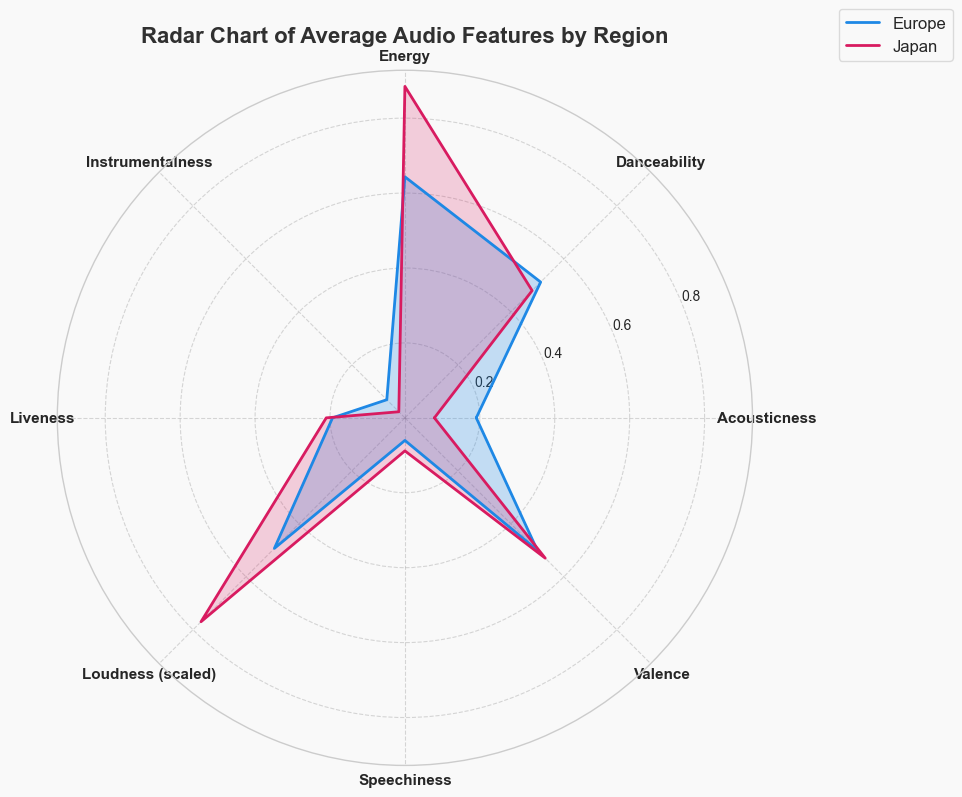

In [193]:
def radar_chart(df):
    stats = df.groupby("Region", observed=False)[music_char].mean().reset_index()

    categories = music_char
    N = len(categories)
    
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]  

    fig = plt.figure(figsize=(10, 8), facecolor='#f9f9f9')
    ax = fig.add_subplot(111, polar=True)

    for i, row in stats.iterrows():
        values = row[categories].tolist()
        values += values[:1] 
        
        region = row['Region']
        color = region_colors[region]
        
        alpha_fill = 0.25 if region == 'Europe' else 0.2
        
        ax.plot(angles, values, linewidth=2, color=color, label=region)
        ax.fill(angles, values, color=color, alpha=alpha_fill)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=11, fontweight='bold')

    ax.grid(True, color='gray', alpha=0.3, linestyle='--')

    ax.set_title("Radar Chart of Average Audio Features by Region", 
                 size=16, pad=20, fontweight='bold', color='#303030')

    legend = ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), 
                       frameon=True, fontsize=12, framealpha=0.8)
    frame = legend.get_frame()
    frame.set_facecolor('#f9f9f9')
    frame.set_edgecolor('lightgray')

    plt.tight_layout()
    plt.show()

radar_chart(df)

#### **🎼 Tonal Mode by Key**
This chart displays the mode inclination (major/minor) within each musical key.

* Major mode slightly dominates over minor across all keys.

* Some keys show a clear preference for one mode over the other – for example, *B minor* and *C major* stand out.

  This might suggest:
  * Certain keys are easier to play in specific modes.
  * Certain tonalities better convey specific emotional moods.

📌 **Note:** This visualization does not reflect the total number of songs – it only shows the relative modal distribution within each key.

<Figure size 1400x700 with 0 Axes>

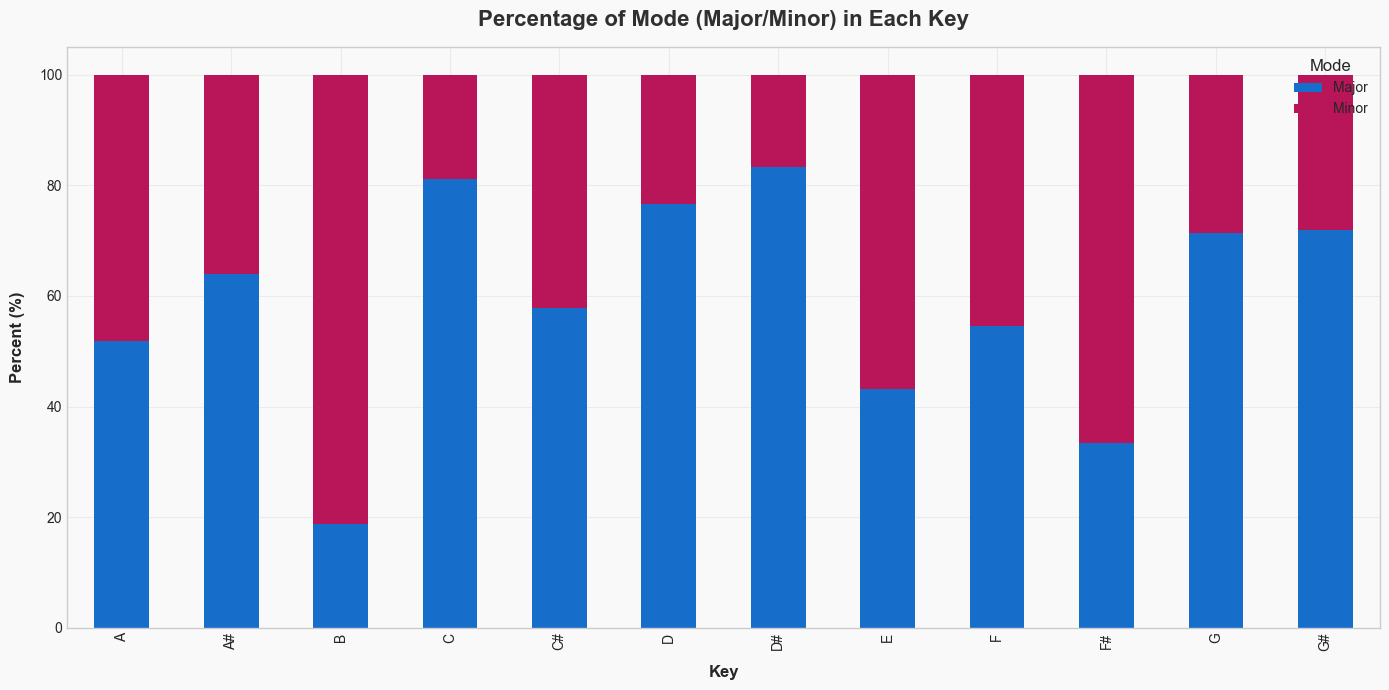

In [194]:
key_mode_counts = df.groupby(['Key', 'Mode'], observed=False).size().unstack().fillna(0)
key_mode_percent = key_mode_counts.div(key_mode_counts.sum(axis=1), axis=0) * 100

plt.figure(figsize=(14, 7), facecolor='#f9f9f9')
ax = key_mode_percent.plot(kind='bar', stacked=True, figsize=(14, 7), 
                     color=[blue_gradient(0.7), pink_gradient(0.7)])

plt.title('Percentage of Mode (Major/Minor) in Each Key', fontsize=16, fontweight='bold', pad=15, color='#303030')
plt.xlabel('Key', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Percent (%)', fontsize=12, fontweight='bold', labelpad=10)

legend = plt.legend(title='Mode', fontsize=10, title_fontsize=12)
legend.get_frame().set_alpha(0.8)
legend.get_frame().set_edgecolor('lightgray')

plt.grid(True, axis='y', alpha=0.3)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

#### **🔍 Correlation Matrix Insights by Region**
##### **🇯🇵 Japan**
* **Acousticness** has a **strong negative correlation** with energy (-0.72), indicating that acoustic tracks tend to be less energetic.

* **Valence** (positivity) is somewhat influenced by danceability.

* Tracks with higher **speechiness** (e.g. rap-like elements) and loudness tend to be more energetic.

* Interestingly, there's a **negative correlation between danceability and energy**, which may seem counterintuitive.
This could imply that in Japanese music, **less rhythmic (less danceable)** songs are more energetic, perhaps reflecting unique stylistic trends.

* Surprisingly, **acoustic tracks in Japan** are **more danceable**, unlike typical Europe patterns.

##### **🇪🇺 Europe**
* As in Japan, **acoustic songs are less energetic**.

* **Energy** shows a **strong positive correlation with loudness**, which makes sense — louder tracks tend to feel more intense or powerful.

* **Speechiness** also correlates with energy, similarly to the Japanese case.

* **Valence** is positively related to **danceability, energy**, and to some extent, **loudness**, which supports the idea that more upbeat, energetic songs tend to feel more positive.

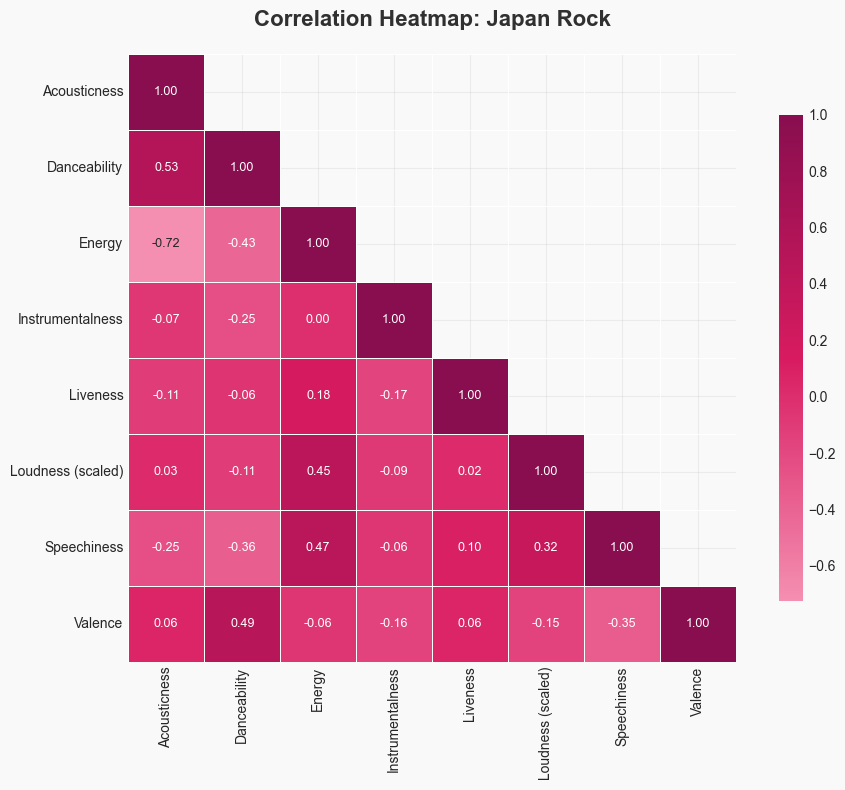

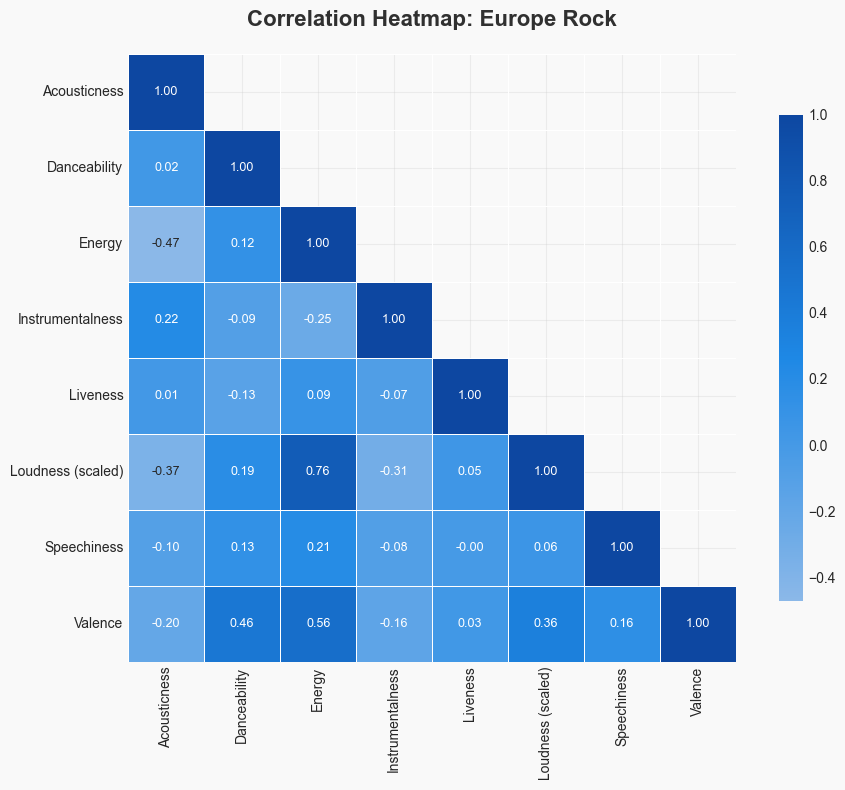

In [195]:
for region in df['Region'].unique():
    plt.figure(figsize=(10, 8), facecolor='#f9f9f9')
    corr = df[df['Region'] == region][music_char].corr()
    
    cmap = blue_gradient if region == 'Europe' else pink_gradient
    
    mask = np.zeros_like(corr)
    mask[np.triu_indices_from(mask, k=1)] = True
    
    sns.heatmap(corr, annot=True, cmap=cmap, mask=mask, linewidths=0.5, 
                annot_kws={"size": 9}, fmt='.2f', square=True, cbar_kws={"shrink": .8})
    
    plt.title(f"Correlation Heatmap: {region} Rock", fontsize=16, 
              fontweight='bold', pad=20, color='#303030')
    
    plt.tight_layout()
    plt.show()

## **Audio characteristics of songs**

#### **🎸 Comparison of Audio Characteristics by Region**

We analyzed the following **audio features** to compare rock music between **Europe** and **Japan**:
* **Loudness**
* **Danceability**
* **Energy**
* **Valence**

---

##### **Loudness**

* **Japanese rock tracks are noticeably louder** on average than European ones.
* This may reflect **different mastering practices** or stylistic emphasis, and could serve as a **key distinguishing feature** between regions.

---

##### **Danceability**

* **European rock** is generally **more danceable**.
* However, the **interquartile range** for both regions is quite similar, indicating comparable variability.

---

##### **Energy**

* **Japanese rock** is significantly more energetic.
* Most tracks from Japan show **very high energy values (0.8–1.0)**.
* In contrast, **European rock** shows a more **balanced distribution** of energy, without such a pronounced skew.

---

##### **Valence**

* The **overall emotional tone (valence)** is **quite similar** across both regions.
* Both tend to have **mid-range valence values**, indicating **ambiguous or neutral emotional coloring** – neither distinctly happy nor sad.

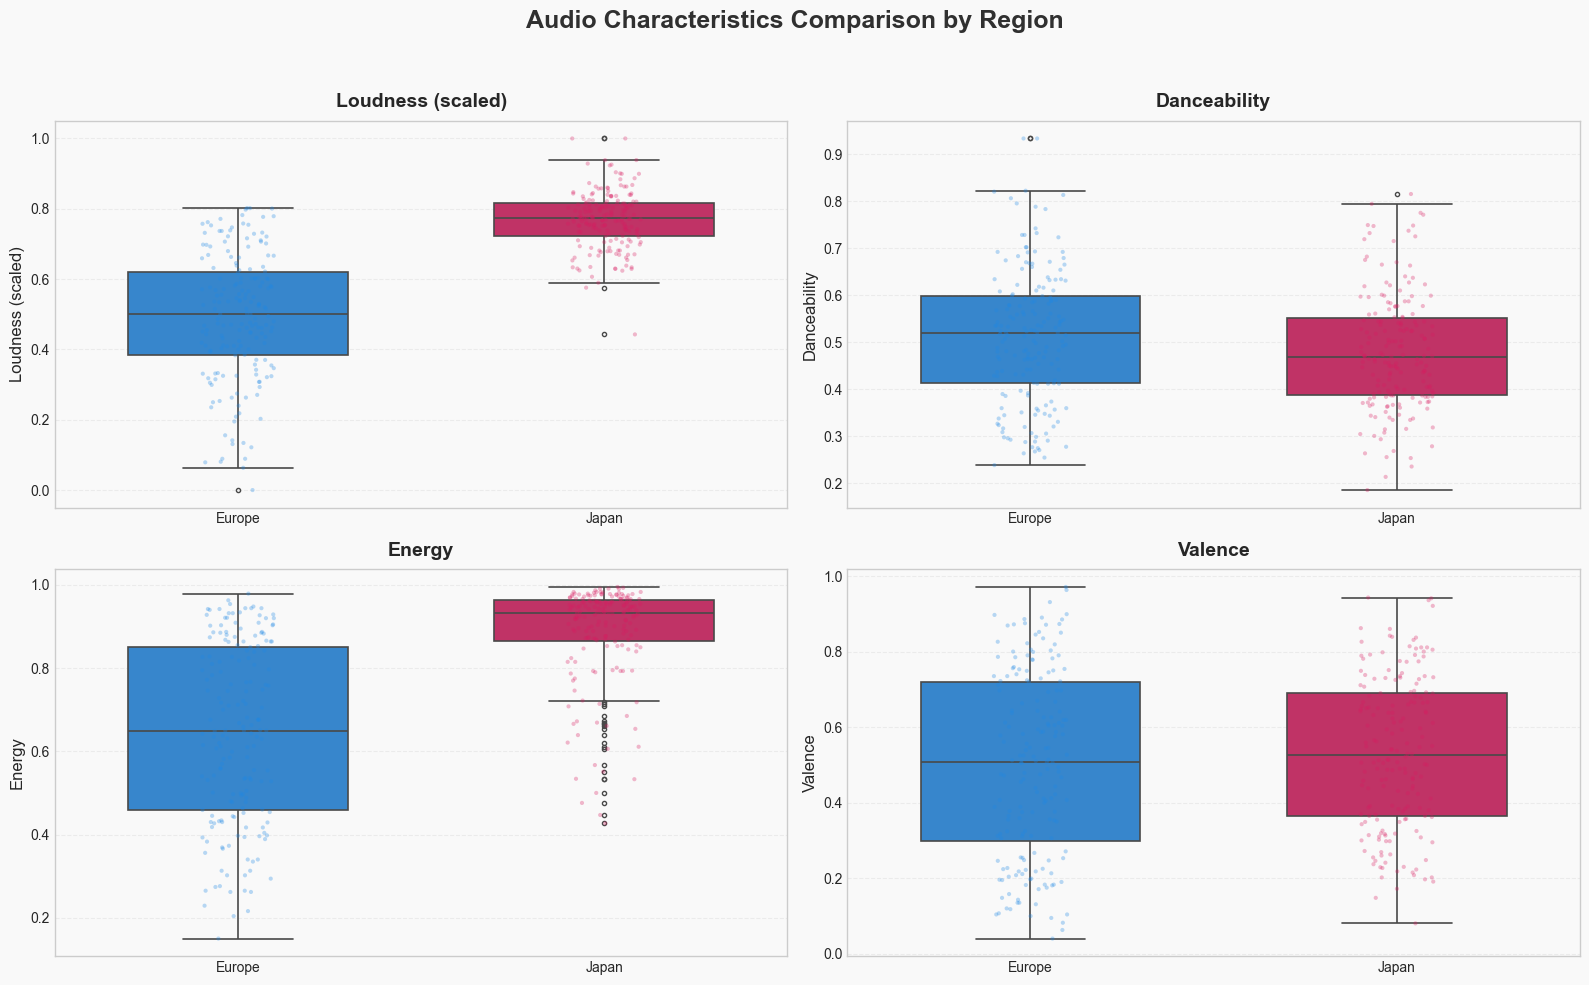

In [196]:
plt.figure(figsize=(16, 10), facecolor='#f9f9f9')

for i, col in enumerate(tone_cols, 1):
    plt.subplot(2, 2, i)
    
    sns.boxplot(data=df, y=col, x='Region', hue='Region', 
                palette=compare_palette, width=0.6,
                fliersize=3, linewidth=1.2)

    plt.legend([],[], frameon=False)

    sns.stripplot(data=df, y=col, x='Region', hue='Region', 
                 palette=compare_palette, size=3, alpha=0.3, jitter=True)

    plt.title(col, fontsize=14, fontweight='bold', pad=10)
    plt.xlabel('')
    plt.ylabel(col, fontsize=12)
    plt.grid(True, axis='y', alpha=0.3, linestyle='--')

plt.suptitle('Audio Characteristics Comparison by Region', 
             fontsize=18, fontweight='bold', y=0.98, color='#303030')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

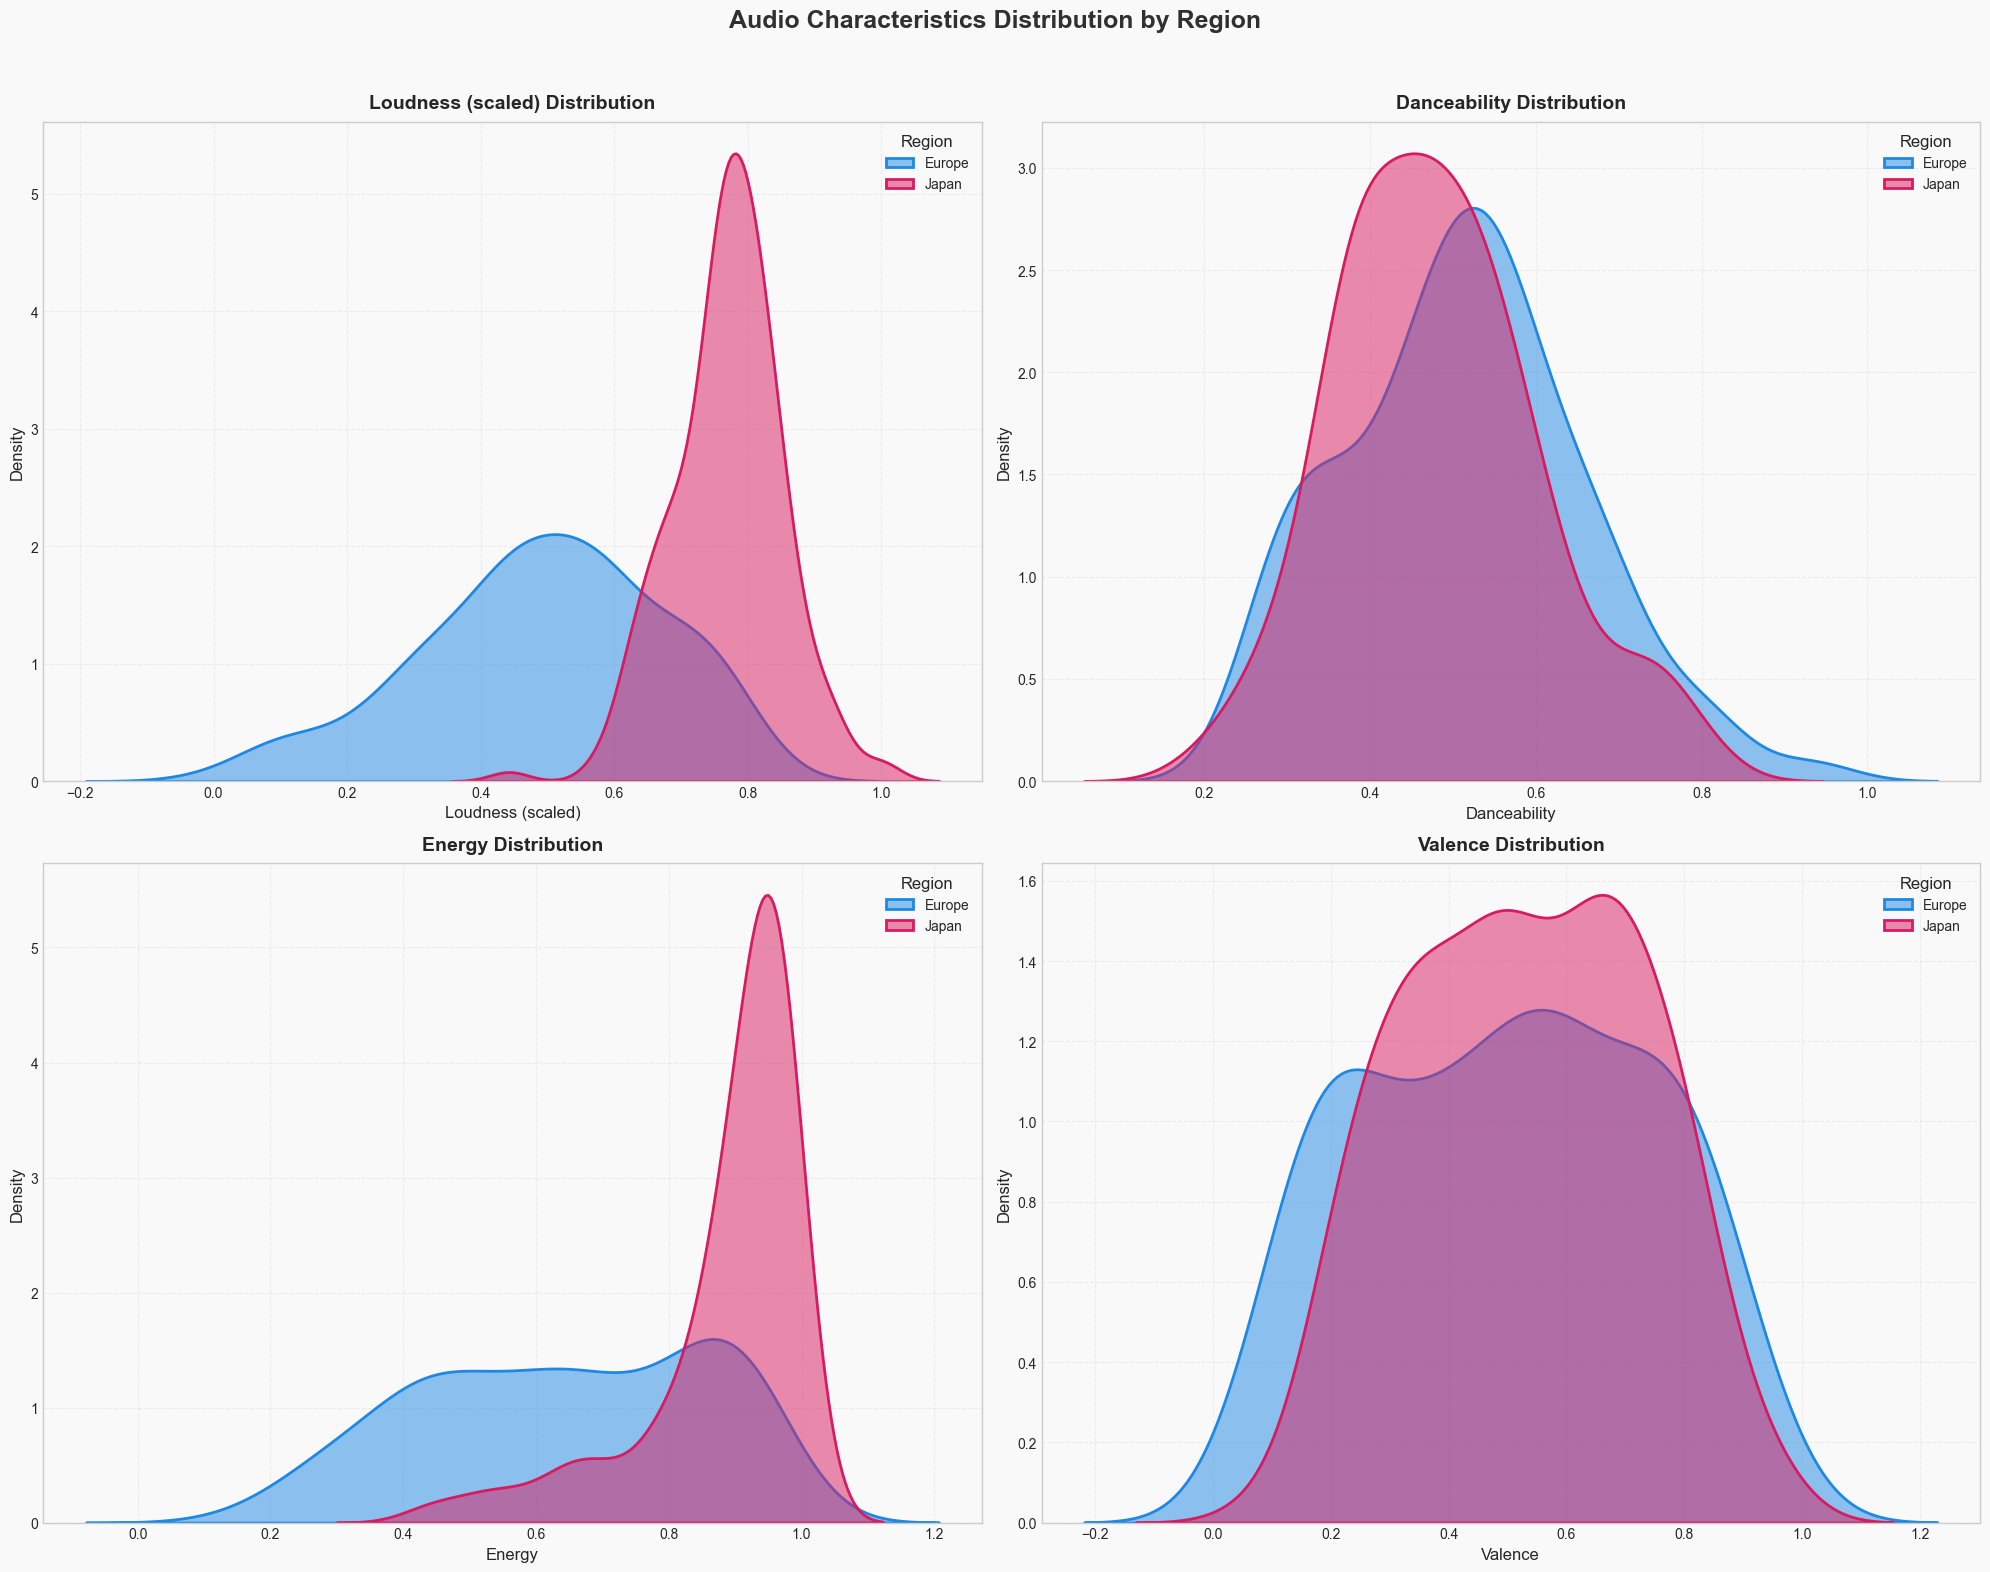

In [197]:
plt.figure(figsize=(20, 16), facecolor='#f9f9f9')

for i, col in enumerate(tone_cols, 1):
    plt.subplot(2, 2, i)

    sns.kdeplot(data=df[df['Region'] == 'Europe'], x=col, 
                fill=True, common_norm=False, alpha=0.5, 
                color=region_colors['Europe'], linewidth=2, label='Europe')

    sns.kdeplot(data=df[df['Region'] == 'Japan'], x=col, 
                fill=True, common_norm=False, alpha=0.5, 
                color=region_colors['Japan'], linewidth=2, label='Japan')

    plt.title(f"{col} Distribution", fontsize=14, fontweight='bold', pad=10)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.grid(True, alpha=0.3, linestyle='--')

    legend = plt.legend(title='Region', fontsize=10, title_fontsize=12)
    legend.get_frame().set_alpha(0.8)
    legend.get_frame().set_edgecolor('lightgray')

plt.suptitle("Audio Characteristics Distribution by Region", 
             fontsize=18, fontweight='bold', y=0.98, color='#303030')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## **Musical structure**

#### 🔊 **Comparison of Musical Structure by Features**

We analyzed the following structural and technical audio features:

* **Instrumentalness**
* **Speechiness**
* **Liveness**
* **Acousticness**
* **Tempo**

---

##### **Instrumentalness**

* Both **Japanese** and **European rock** are largely **vocal-instrumental**, with vocals being a key element.
* Outliers with high values (0.9–1.0) likely represent **fully instrumental tracks**.
* Mid-range outliers may indicate **extended instrumental solos or bridges**.

---

##### **Speechiness**

* Both regions show **low levels of speechiness**, which is expected as rock typically contrasts with genres like rap.
* However, **Japanese tracks tend to have slightly higher speechiness**, possibly due to:

  * **Spoken-word or recitative sections** in vocals,
  * **Linguistic traits** of the Japanese language,
  * Or **expressive performance styles** more common in J-rock.

---

##### **Liveness**

* Most tracks in both regions show **low liveness**, suggesting **studio recordings**.
* Occasional outliers may correspond to **live performances** or live-recorded versions.
* This feature is interesting, though the precise methodology behind its calculation remains unclear.

---

##### **Acousticness**

* European rock tends to include **more acoustic instruments**, such as acoustic guitar or piano.
* The outliers likely represent **fully acoustic tracks** with minimal or no electric instrumentation.

---

##### **Tempo**

* **Japanese rock music displays greater tempo variability** and tends to be **faster on average**.
* This could indicate **a broader stylistic range** or **a preference for higher-energy arrangements**.

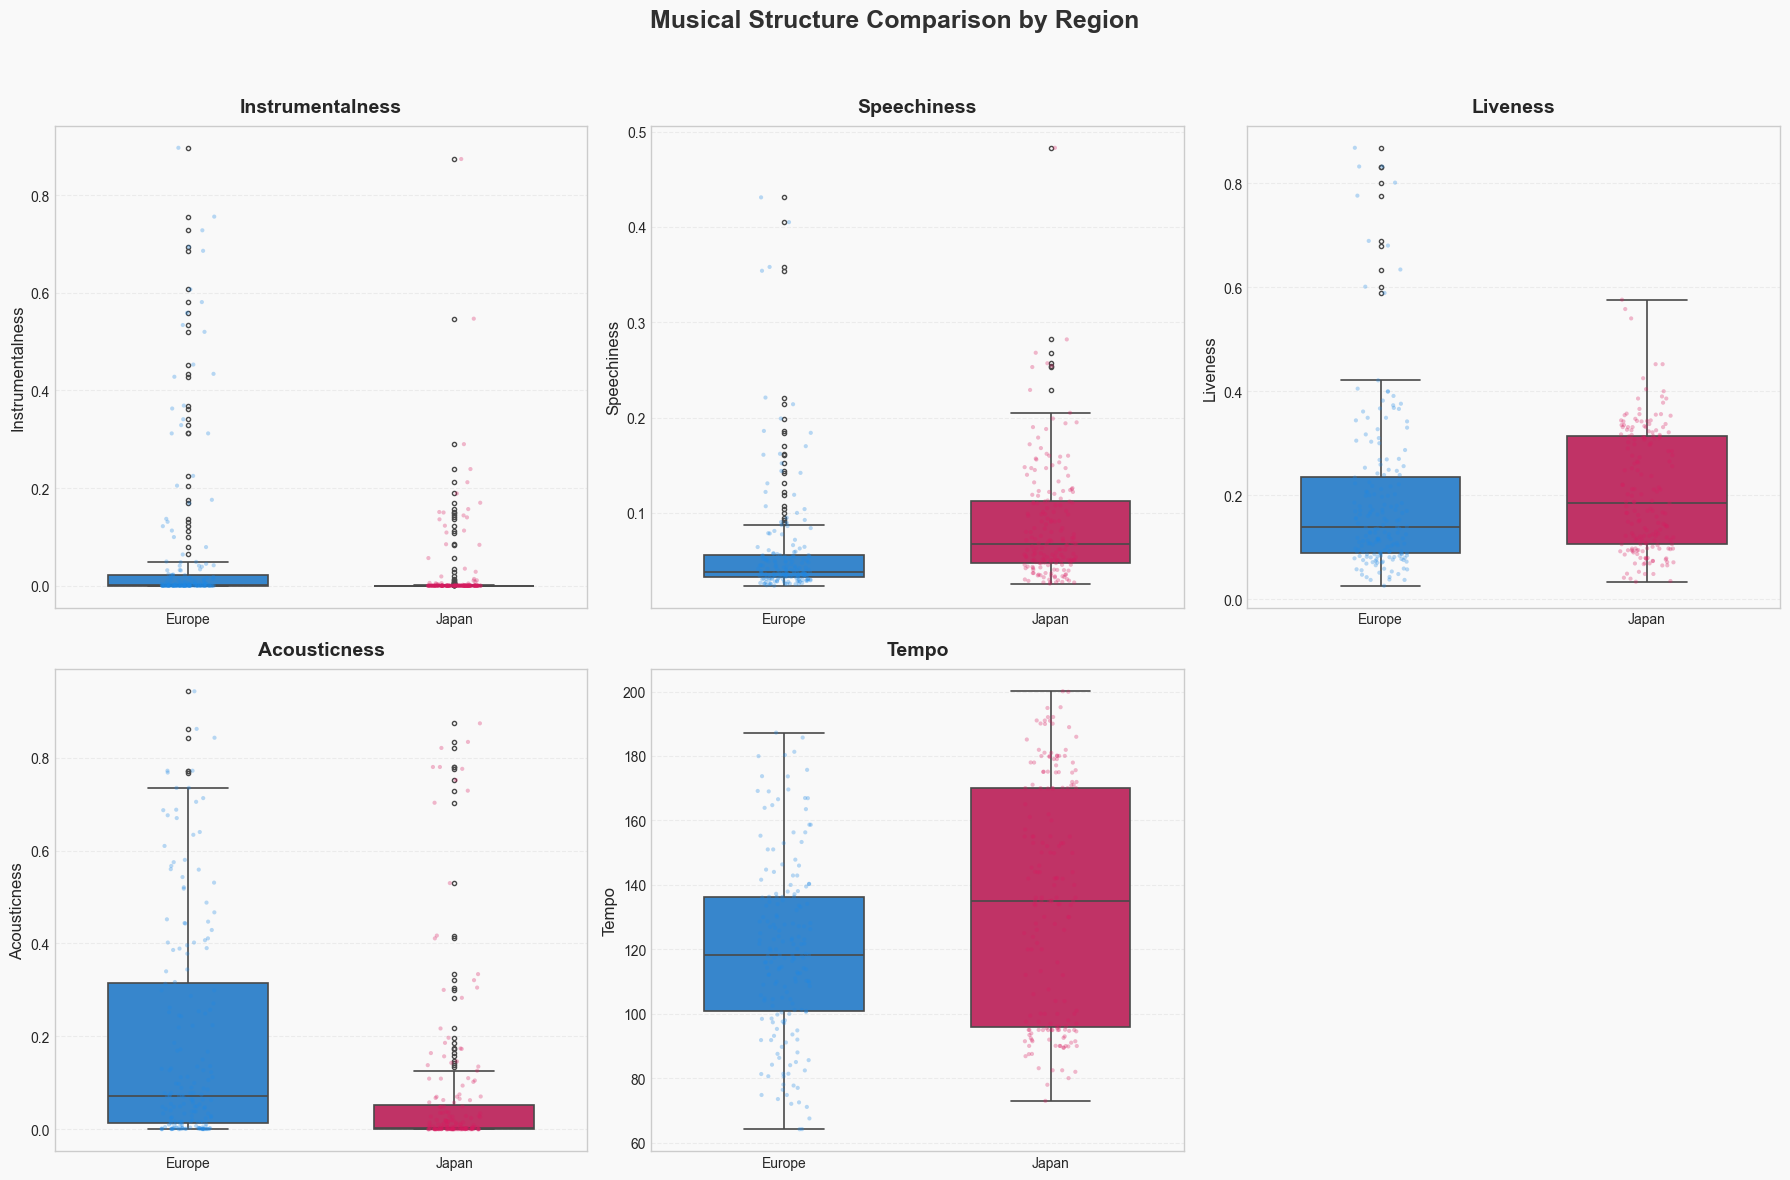

In [198]:
plt.figure(figsize=(18, 12), facecolor='#f9f9f9')

for i, col in enumerate(arrangement_cols, 1):
    plt.subplot(2, 3, i)
    
    sns.boxplot(data=df, y=col, x='Region', hue='Region', 
                palette=compare_palette, width=0.6,
                fliersize=3, linewidth=1.2)
    
    plt.legend([],[], frameon=False)

    sns.stripplot(data=df, y=col, x='Region', hue='Region', 
                 palette=compare_palette, size=3, alpha=0.3, jitter=True)
    
    plt.title(col, fontsize=14, fontweight='bold', pad=10)
    plt.xlabel('')
    plt.ylabel(col, fontsize=12)
    plt.grid(True, axis='y', alpha=0.3, linestyle='--')

plt.suptitle('Musical Structure Comparison by Region', 
             fontsize=18, fontweight='bold', y=0.98, color='#303030')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

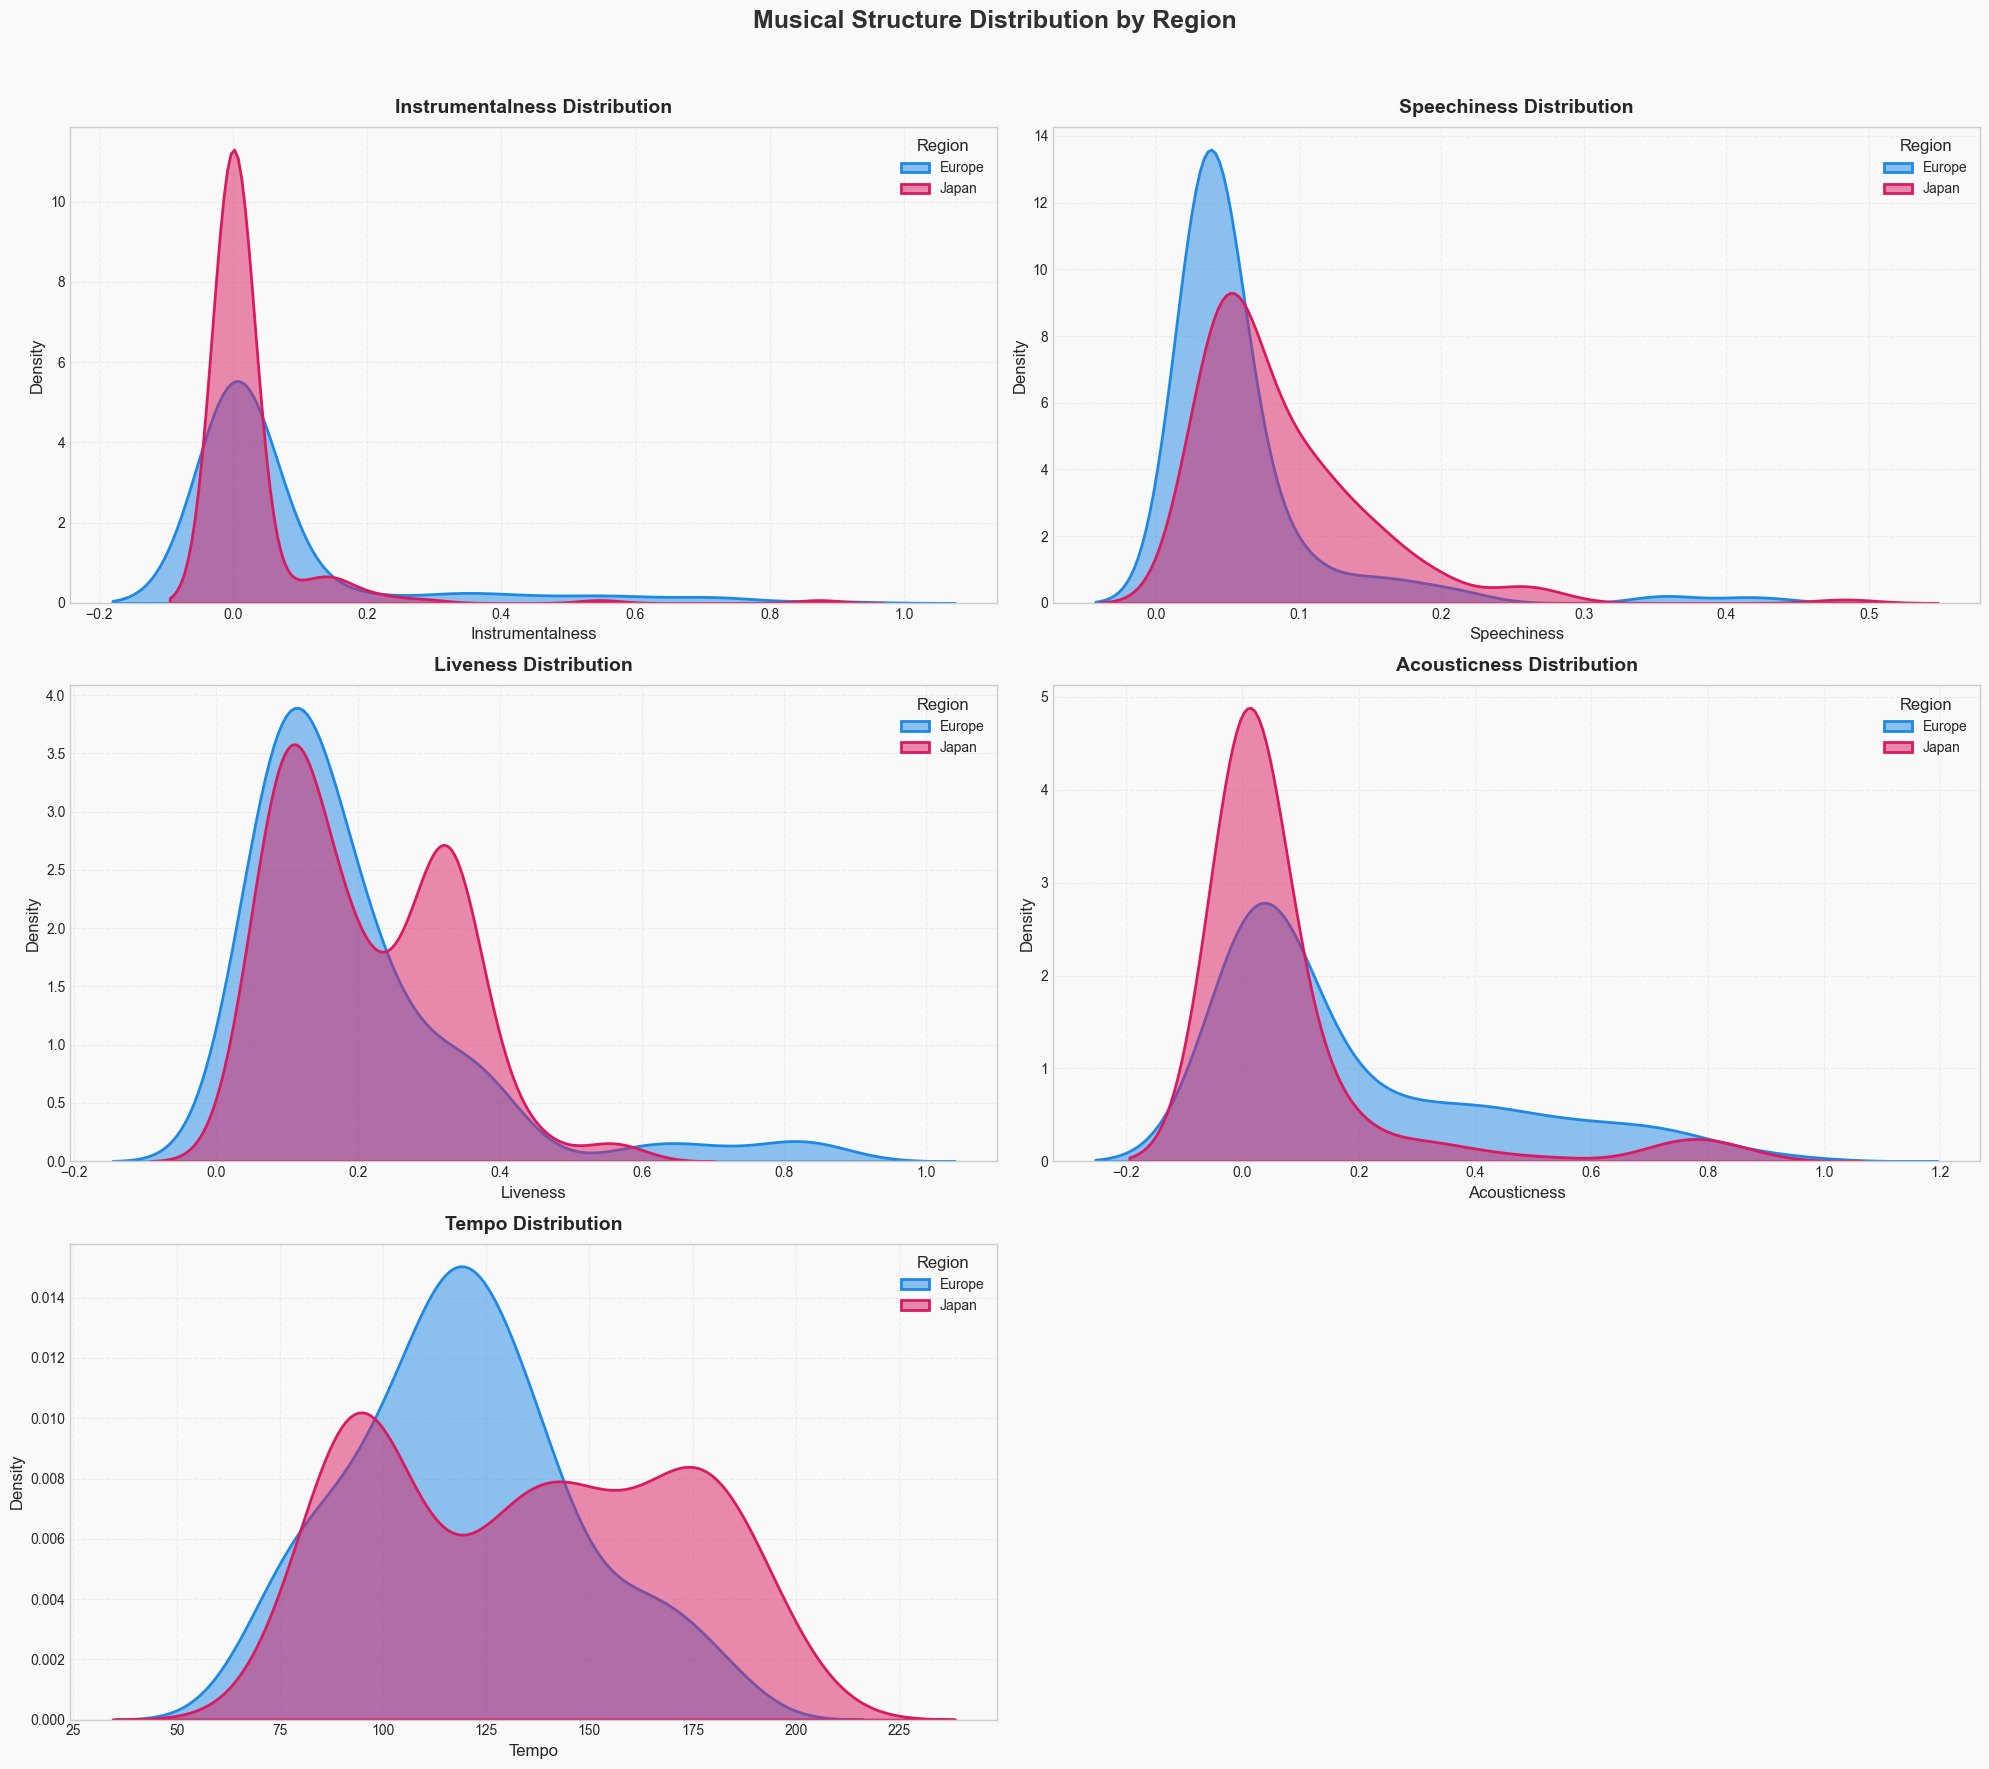

In [199]:
plt.figure(figsize=(20, 18), facecolor='#f9f9f9')

for i, col in enumerate(arrangement_cols, 1):
    plt.subplot(3, 2, i)

    sns.kdeplot(data=df[df['Region'] == 'Europe'], x=col, 
                fill=True, common_norm=False, alpha=0.5, 
                color=region_colors['Europe'], linewidth=2, label='Europe')

    sns.kdeplot(data=df[df['Region'] == 'Japan'], x=col, 
                fill=True, common_norm=False, alpha=0.5, 
                color=region_colors['Japan'], linewidth=2, label='Japan')

    plt.title(f"{col} Distribution", fontsize=14, fontweight='bold', pad=10)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.grid(True, alpha=0.3, linestyle='--')

    legend = plt.legend(title='Region', fontsize=10, title_fontsize=12)
    legend.get_frame().set_alpha(0.8)
    legend.get_frame().set_edgecolor('lightgray')

plt.suptitle("Musical Structure Distribution by Region", 
             fontsize=18, fontweight='bold', y=0.98, color='#303030')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## **Popularity** 

In [200]:
df['Year'] = df['Release date'].dt.year

#### 🎵 Popularity Comparison Between European and Japanese Rock

* **European rock is generally more popular than Japanese rock**, both overall and on average.
* This could be due to a **broader audience base** for European rock, as it is listened to in many countries worldwide.
* Additionally, **European rock might be more accessible** to listeners in terms of audio characteristics — it tends to be less loud and has more moderate values across audio features.
* Notably, some Japanese tracks in the dataset have a popularity score of zero, which may reflect niche appeal or limited exposure.

---

#### ⏳ Popularity Trends Over Time

* **Older European rock (pre-2000s) remains fairly popular**, indicating lasting appeal of classic tracks.
* After the 2000s, there is a small **dips in popularity**, but it still remains a popular musical direction, though some years lack sufficient data for firm conclusions.
* **Japanese rock tracks mostly appear starting from the early 2000s**, suggesting this style is relatively young.
* The rising number and popularity of recent Japanese rock tracks may indicate that the genre has been **gaining traction and popularity in recent years**.

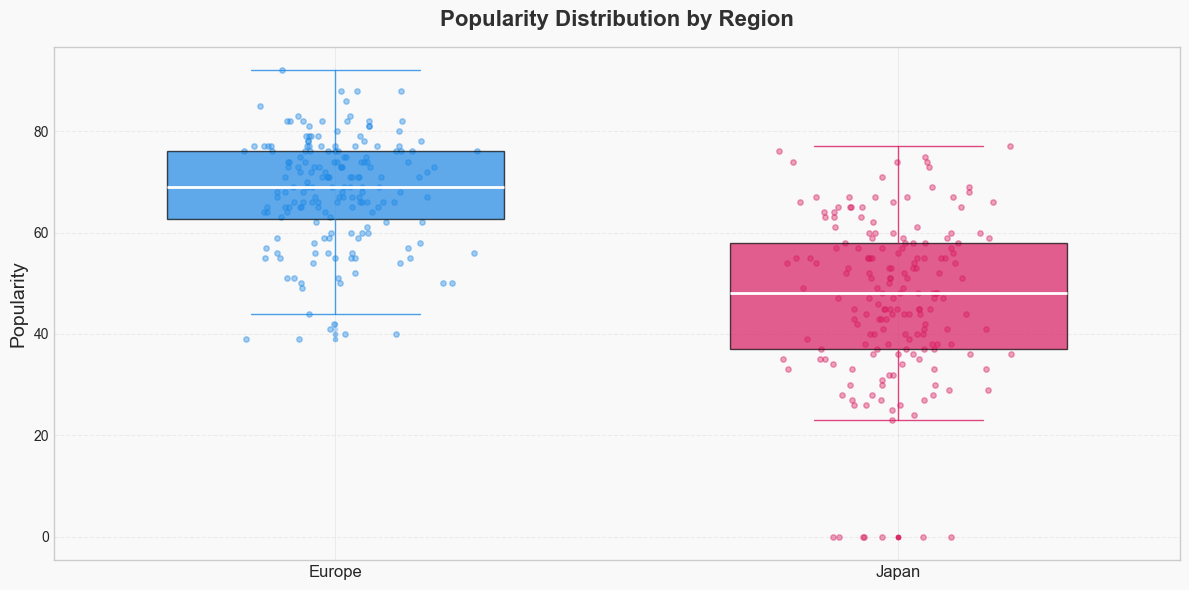

In [201]:
plt.figure(figsize=(12, 6), facecolor='#f9f9f9')

for i, region in enumerate(['Europe', 'Japan']):
    data = df[df['Region'] == region]['Popularity']
    box_position = i
    color = region_colors[region]

    bp = plt.boxplot(data, positions=[box_position], patch_artist=True, 
                    widths=0.6, showfliers=True, showcaps=True)

    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    for whisker in bp['whiskers']:
        whisker.set_color(color)
        whisker.set_alpha(0.8)
        whisker.set_linestyle('-')
        
    for cap in bp['caps']:
        cap.set_color(color)
        cap.set_alpha(0.8)
        
    for median in bp['medians']:
        median.set_color('white')
        median.set_linewidth(2)
        
    for flier in bp['fliers']:
        flier.set_markerfacecolor(color)
        flier.set_markeredgecolor('none')
        flier.set_alpha(0.3)
        flier.set_markersize(4)

for i, region in enumerate(['Europe', 'Japan']):
    data = df[df['Region'] == region]['Popularity']
    x = np.random.normal(i, 0.08, size=len(data)) 
    plt.scatter(x, data, alpha=0.4, s=15, color=region_colors[region])

plt.title('Popularity Distribution by Region', fontsize=16, fontweight='bold', pad=15, color='#303030')
plt.ylabel('Popularity', fontsize=14)
plt.xticks([0, 1], ['Europe', 'Japan'], fontsize=12)
plt.grid(True, axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

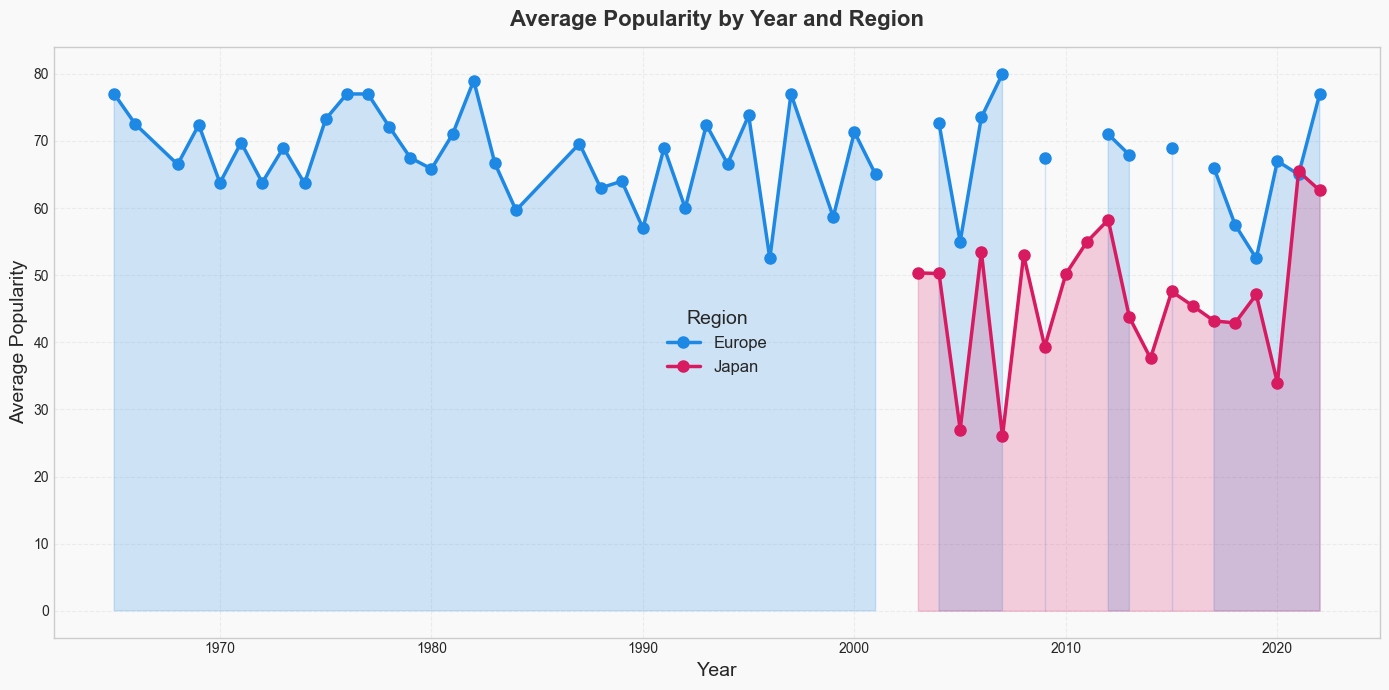

In [202]:
plt.figure(figsize=(14, 7), facecolor='#f9f9f9')
popularity_yearly = df.groupby(['Year', 'Region'], observed=False)['Popularity'].mean().reset_index()

for region in ['Europe', 'Japan']:
    data = popularity_yearly[popularity_yearly['Region'] == region]
    color = region_colors[region]

    data = data.sort_values('Year')
    
    plt.plot(data['Year'], data['Popularity'], marker='o', linewidth=2.5, 
             markersize=8, color=color, label=region)
    
    plt.fill_between(data['Year'], data['Popularity'], alpha=0.2, color=color)

plt.title('Average Popularity by Year and Region', fontsize=16, fontweight='bold', pad=15, color='#303030')
plt.ylabel('Average Popularity', fontsize=14)
plt.xlabel('Year', fontsize=14)
plt.grid(True, alpha=0.3, linestyle='--')

legend = plt.legend(title='Region', fontsize=12, title_fontsize=14)
legend.get_frame().set_alpha(0.8)
legend.get_frame().set_edgecolor('lightgray')

plt.tight_layout()
plt.show()

## **Song duration**

In [203]:
df['Duration_min'] = df['Duration'] / 60000 

#### ⏱ Average song length in rock music

* On average, **rock songs are between 3 and 4 minutes long**, which corresponds to the standard track length in popular music.
* The lengths are **quite concentrated** around this range, which may indicate some similarities in song structure across regions.
* In **Japanese rock music, there are sometimes **tracks with a duration of less than 2 minutes**, which may be indicative of experimental compositions.
* Meanwhile, **European rock is more likely to include longer tracks** - **over 6 minutes**, which may be due to long solos, progressive structures or live performance versions.

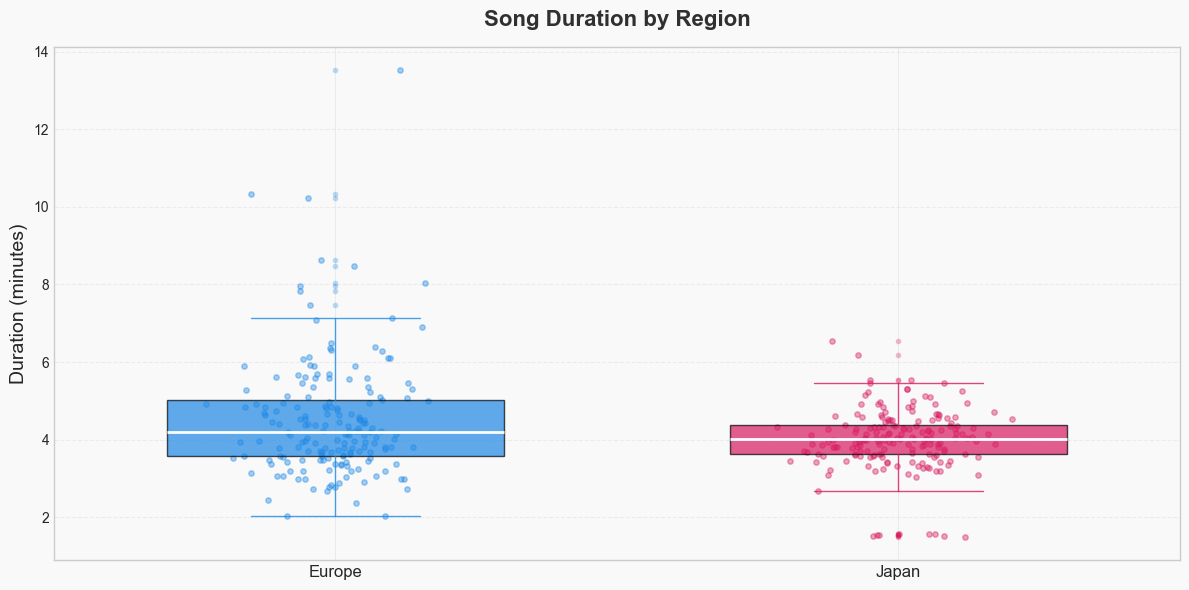

In [204]:
plt.figure(figsize=(12, 6), facecolor='#f9f9f9')

for i, region in enumerate(['Europe', 'Japan']):
    data = df[df['Region'] == region]['Duration_min']
    box_position = i
    color = region_colors[region]

    bp = plt.boxplot(data, positions=[box_position], patch_artist=True, 
                    widths=0.6, showfliers=True, showcaps=True)

    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    for whisker in bp['whiskers']:
        whisker.set_color(color)
        whisker.set_alpha(0.8)
        whisker.set_linestyle('-')
        
    for cap in bp['caps']:
        cap.set_color(color)
        cap.set_alpha(0.8)
        
    for median in bp['medians']:
        median.set_color('white')
        median.set_linewidth(2)
        
    for flier in bp['fliers']:
        flier.set_markerfacecolor(color)
        flier.set_markeredgecolor('none')
        flier.set_alpha(0.3)
        flier.set_markersize(4)

for i, region in enumerate(['Europe', 'Japan']):
    data = df[df['Region'] == region]['Duration_min']
    x = np.random.normal(i, 0.08, size=len(data)) 
    plt.scatter(x, data, alpha=0.4, s=15, color=region_colors[region])

plt.title('Song Duration by Region', fontsize=16, fontweight='bold', pad=15, color='#303030')
plt.ylabel('Duration (minutes)', fontsize=14)
plt.xticks([0, 1], ['Europe', 'Japan'], fontsize=12)
plt.grid(True, axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

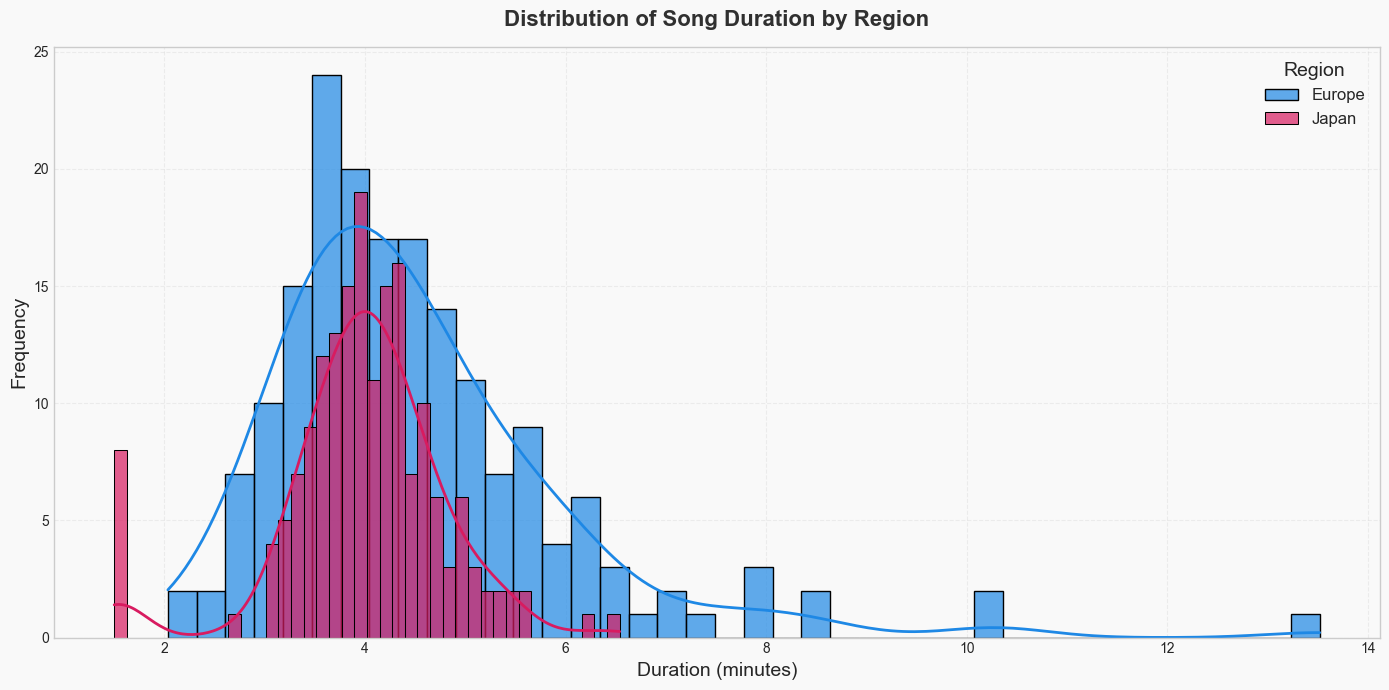

In [205]:
plt.figure(figsize=(14, 7), facecolor='#f9f9f9')

sns.histplot(data=df[df['Region'] == 'Europe'], x='Duration_min', 
            kde=True, bins=40, alpha=0.7, color=region_colors['Europe'], 
            label='Europe', line_kws={'linewidth': 2})

sns.histplot(data=df[df['Region'] == 'Japan'], x='Duration_min', 
            kde=True, bins=40, alpha=0.7, color=region_colors['Japan'], 
            label='Japan', line_kws={'linewidth': 2})

plt.title('Distribution of Song Duration by Region', fontsize=16, fontweight='bold', pad=15, color='#303030')
plt.xlabel('Duration (minutes)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(True, alpha=0.3, linestyle='--')

legend = plt.legend(title='Region', fontsize=12, title_fontsize=14)
legend.get_frame().set_alpha(0.8)
legend.get_frame().set_edgecolor('lightgray')

plt.tight_layout()
plt.show()

## **Tones and moods**

#### 🎼 Keys and modes in rock music

* Simpler pitches (e.g. **C, G, D, F**) are generally more commonly used, especially in **European rock**, indicating a preference for more accessible or traditional pitch centres.
* In contrast, **Japanese rock** often explores **more difficult keys** such as **C♯** and **G♯**, indicating greater tonal variety or experimentation.

#### Modal trends:
* European rock is dominated by **major keys**, which contributes to a more energetic sound.
* In **Japanese rock**, major and minor keys are used more evenly.

This contrast in tonal and modal preferences may reflect **cultural differences in emotional expression through music**.

<Figure size 1400x700 with 0 Axes>

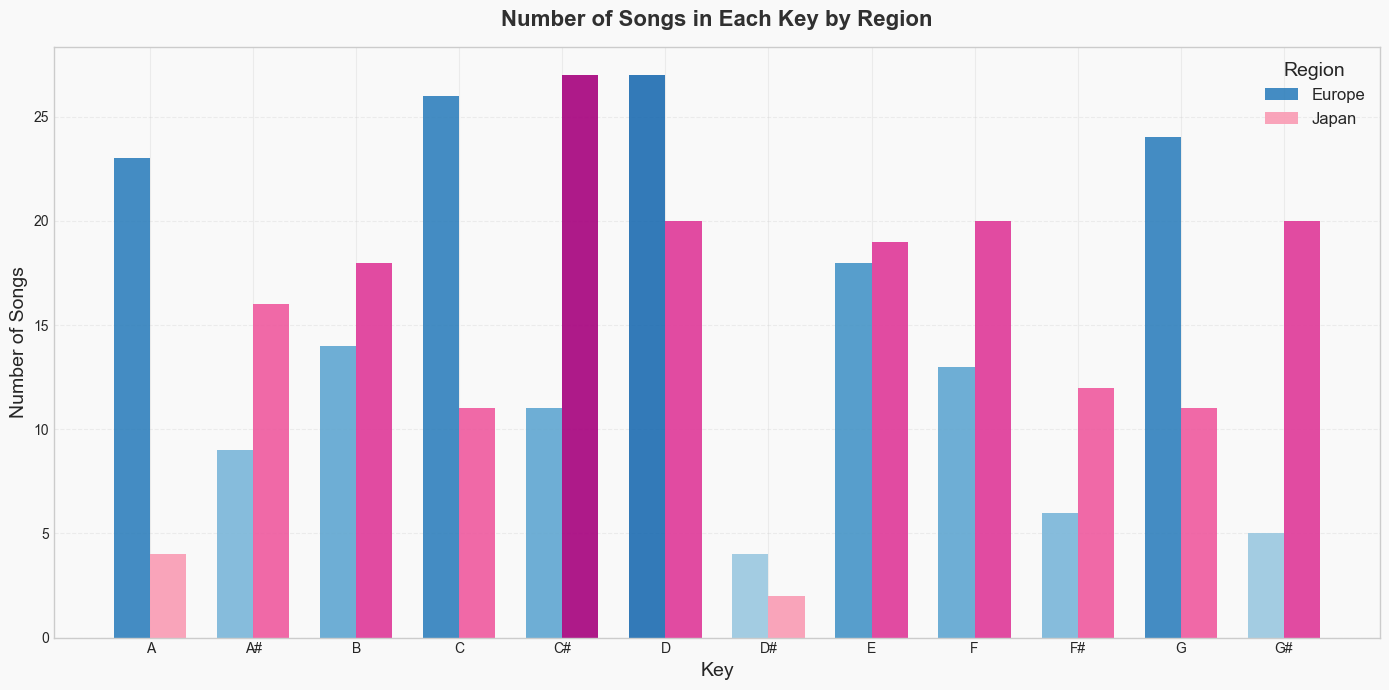

In [206]:
plt.figure(figsize=(14, 7), facecolor='#f9f9f9')

europe_colors = sns.color_palette("Blues", n_colors=12)[4:10]
japan_colors = sns.color_palette("RdPu", n_colors=12)[4:10]

key_counts = df.groupby(['Key', 'Region'], observed=False).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 7), facecolor='#f9f9f9')

keys = key_counts.index.tolist()
x = np.arange(len(keys))
width = 0.35

for i, key in enumerate(keys):
    value = key_counts.loc[key, 'Europe']
    color_idx = min(int(value / key_counts['Europe'].max() * (len(europe_colors)-1)), len(europe_colors)-1)
    ax.bar(x[i] - width/2, value, width, label='Europe' if i == 0 else "", 
           color=europe_colors[color_idx], alpha=0.9)

for i, key in enumerate(keys):
    value = key_counts.loc[key, 'Japan']
    color_idx = min(int(value / key_counts['Japan'].max() * (len(japan_colors)-1)), len(japan_colors)-1)
    ax.bar(x[i] + width/2, value, width, label='Japan' if i == 0 else "", 
           color=japan_colors[color_idx], alpha=0.9)

ax.set_title('Number of Songs in Each Key by Region', fontsize=16, fontweight='bold', pad=15, color='#303030')
ax.set_xlabel('Key', fontsize=14)
ax.set_ylabel('Number of Songs', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(keys)
ax.grid(True, axis='y', alpha=0.3, linestyle='--')

legend = ax.legend(title='Region', fontsize=12, title_fontsize=14)
legend.get_frame().set_alpha(0.8)
legend.get_frame().set_edgecolor('lightgray')

plt.tight_layout()
plt.show()

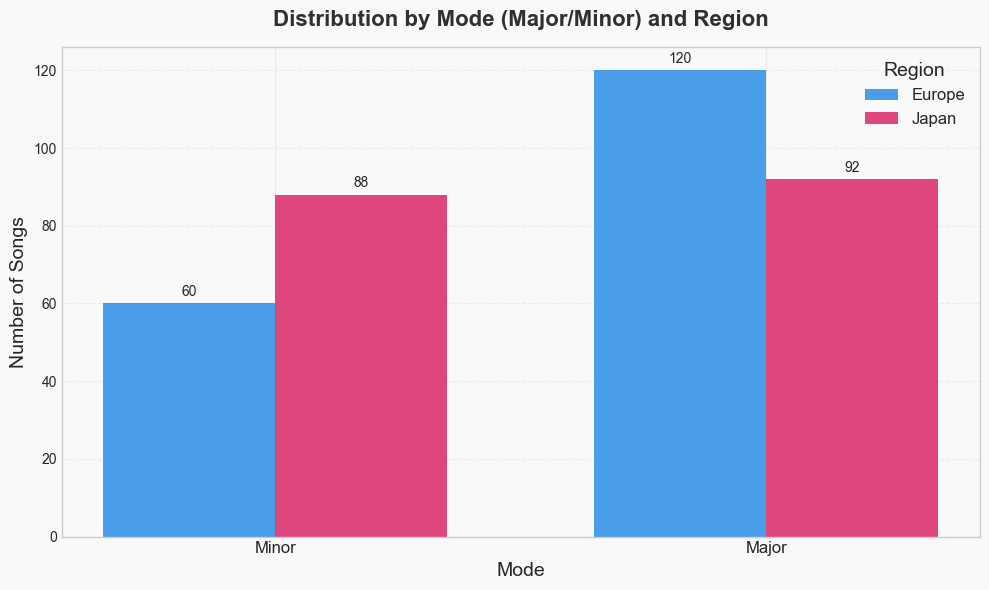

In [207]:
plt.figure(figsize=(10, 6), facecolor='#f9f9f9')
ax = plt.gca()

modes_europe = df[df['Region'] == 'Europe']['Mode'].value_counts()
modes_japan = df[df['Region'] == 'Japan']['Mode'].value_counts()

mode_categories = ['Minor', 'Major']

minor_europe = modes_europe.get('Minor', 0)  
major_europe = modes_europe.get('Major', 0)  

minor_japan = modes_japan.get('Minor', 0)
major_japan = modes_japan.get('Major', 0)

x = np.arange(len(mode_categories))
width = 0.35

rects1 = ax.bar(x - width/2, [minor_europe, major_europe], 
                width, label='Europe', color=region_colors['Europe'], alpha=0.8)
rects2 = ax.bar(x + width/2, [minor_japan, major_japan], 
                width, label='Japan', color=region_colors['Japan'], alpha=0.8)

def add_value_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate('{}'.format(height),
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

add_value_labels(rects1)
add_value_labels(rects2)

plt.title('Distribution by Mode (Major/Minor) and Region', fontsize=16, fontweight='bold', pad=15, color='#303030')
plt.xlabel('Mode', fontsize=14)
plt.ylabel('Number of Songs', fontsize=14)
plt.xticks(x, mode_categories, fontsize=12)
plt.grid(True, axis='y', alpha=0.3, linestyle='--')

legend = plt.legend(title='Region', fontsize=12, title_fontsize=14)
legend.get_frame().set_alpha(0.8)
legend.get_frame().set_edgecolor('lightgray')

plt.tight_layout()
plt.show()

## **Genres by region**

In [208]:
genre_region_counts = df.groupby(['Genre', 'Region'], observed=False).size().unstack(fill_value=0)

#### 🎸 Subgenres of Rock in the Dataset

Despite the wide variety of subgenres detected in the dataset, it's important to consider that Spotify API genre tags may vary depending on the album. Still, the core of the dataset remains centered around **rock bands**.

##### Key Observations:

* **European rock** shows a **greater diversity of subgenres**, indicating a broader stylistic spectrum and perhaps a more complex genre taxonomy within the region.
* **Japanese rock**, in contrast, is represented by only **three subgenres**, with the majority falling under the **"anime"** category. This points to music that has either been used in **Japanese animation** or stylistically aligns with anime culture while remaining rooted in rock music.

There is **no overlap between the subgenres** of European and Japanese rock in this dataset, highlighting distinct cultural and stylistic identities in rock music across the two regions.

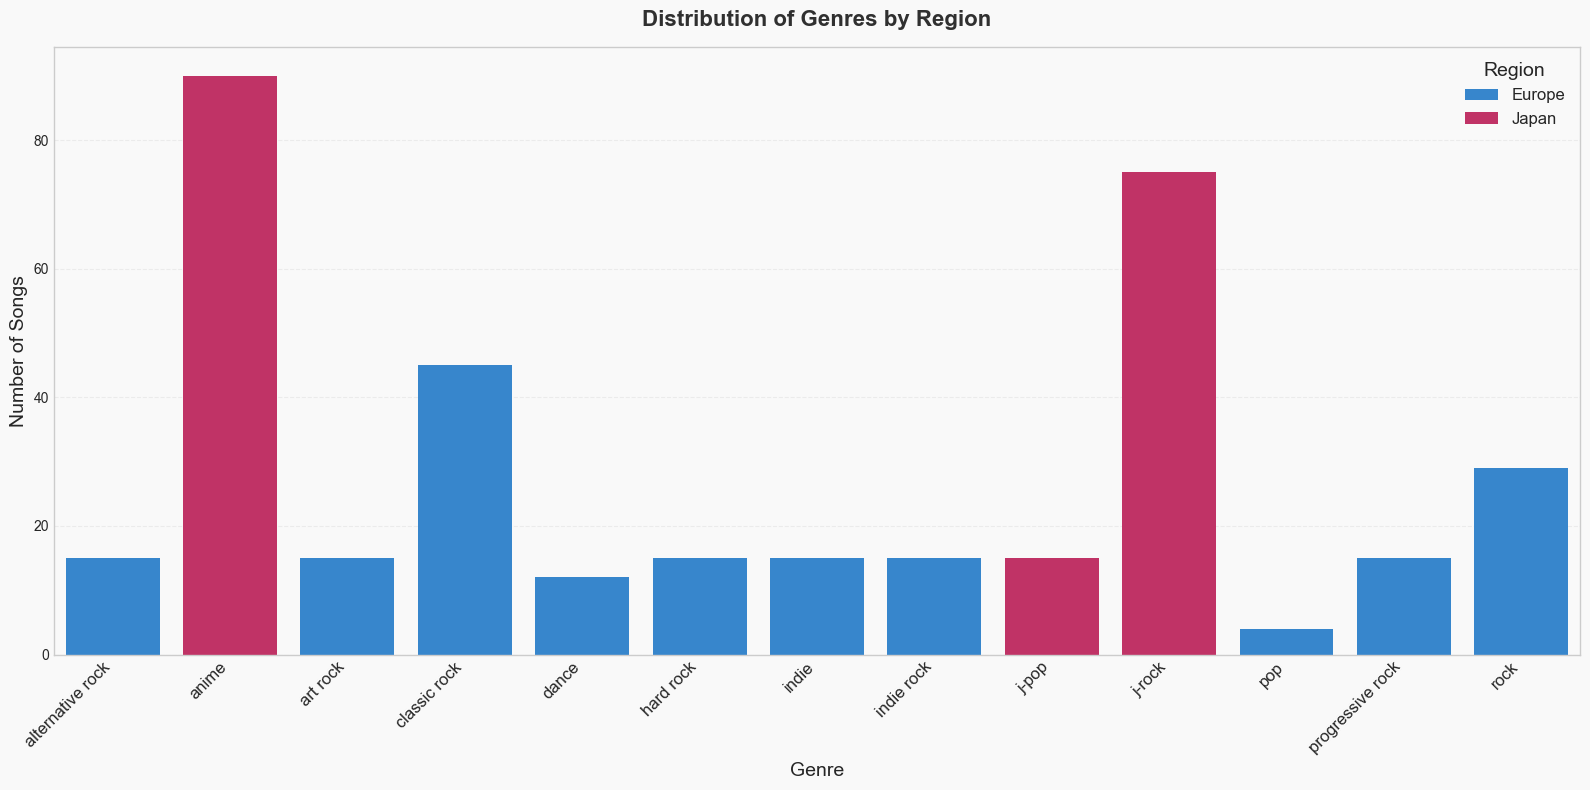

In [209]:
plt.figure(figsize=(16, 8), facecolor='#f9f9f9')

sns.countplot(data=df, x='Genre', hue='Region', 
             palette=[region_colors['Europe'], region_colors['Japan']])

plt.title('Distribution of Genres by Region', fontsize=16, fontweight='bold', pad=15, color='#303030')
plt.xlabel('Genre', fontsize=14)
plt.ylabel('Number of Songs', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.grid(True, axis='y', alpha=0.3, linestyle='--')

legend = plt.legend(title='Region', fontsize=12, title_fontsize=14)
legend.get_frame().set_alpha(0.8)
legend.get_frame().set_edgecolor('lightgray')

plt.tight_layout()
plt.show()

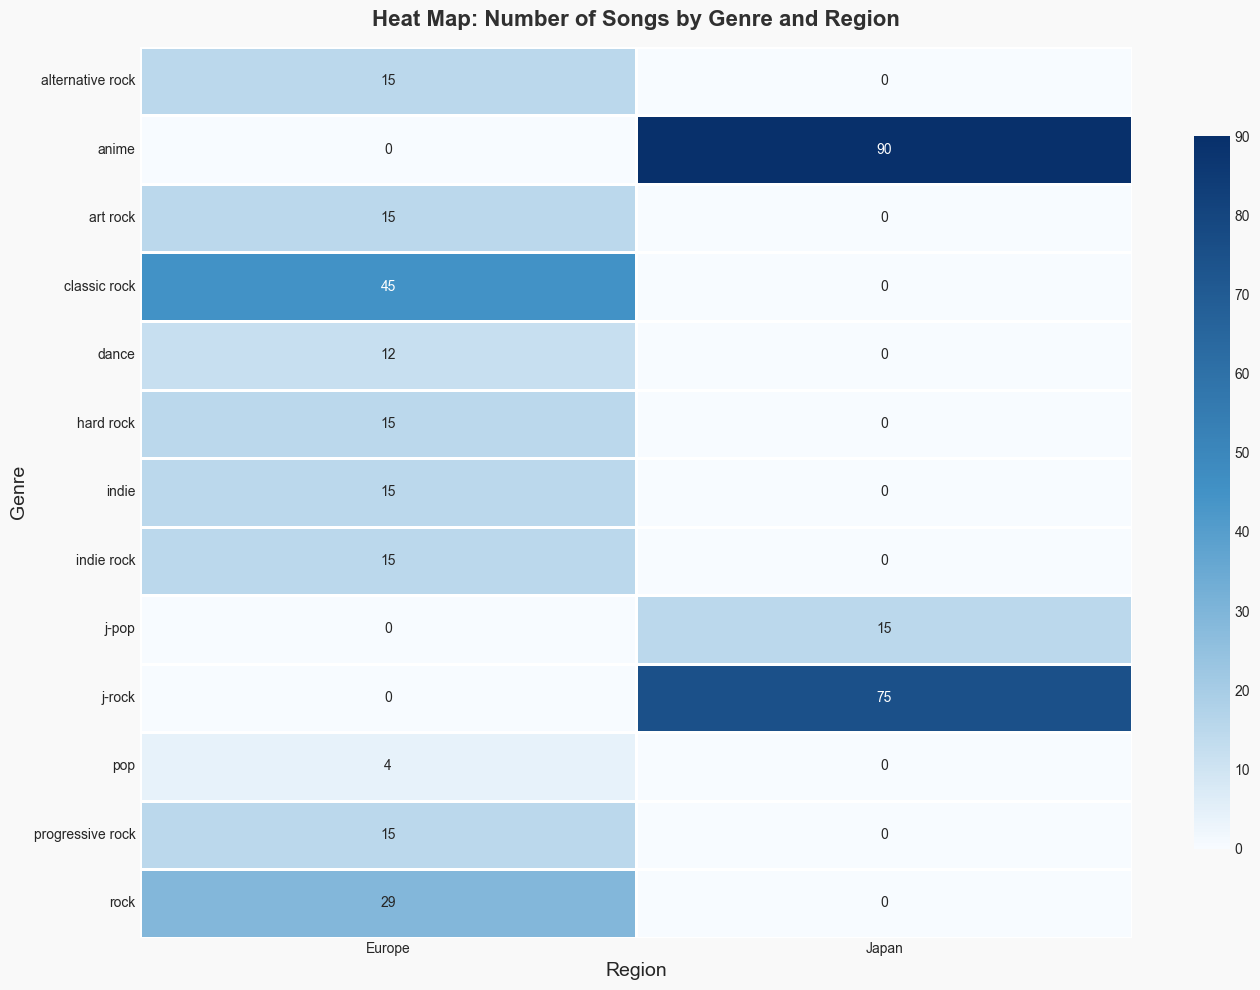

In [210]:
plt.figure(figsize=(14, 10), facecolor='#f9f9f9')

sns.heatmap(genre_region_counts, annot=True, fmt='d', cmap=heatmap_palette, 
            linewidths=0.8, cbar_kws={"shrink": .8})

plt.title('Heat Map: Number of Songs by Genre and Region', 
         fontsize=16, fontweight='bold', pad=15, color='#303030')
plt.xlabel('Region', fontsize=14)
plt.ylabel('Genre', fontsize=14)

for text in plt.gca().texts:
    text.set_fontsize(10)

plt.tight_layout()
plt.show()

# **Clusterization**

In [211]:
features = ['Acousticness', 'Danceability', 'Energy', 'Valence',
            'Instrumentalness', 'Speechiness', 'Liveness', 'Loudness (scaled)', 'Tempo']

In [212]:
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#### **🎯 Clustering Analysis of Rock Tracks**

Using the **elbow method**, the optimal number of clusters was determined to be **k = 3**.

To visualize the clustering in a two-dimensional space, **PCA (Principal Component Analysis)** was applied, reducing the dimensionality of the dataset while preserving its most significant variance. Each point on the plot represents a **single track**, colored by cluster and labeled by region (**Europe** or **Japan**).

##### 📊 Cluster Interpretations:

**Cluster 0:**

* Dominated by **Japanese tracks**, primarily located on the **right side** of the PCA plot.
* Concentration along the **positive PCA1 axis** suggests a distinct set of audio characteristics.
* Likely represents a **unique stylistic identity of Japanese rock**, indicating its **difference** from European rock.

**Cluster 1:**

* A **mix of Japanese and European tracks**, with a stronger presence of European rock.
* Located **centrally**, partially overlapping with Cluster 0.
* This overlap may indicate **shared stylistic elements** between the two regions, reflecting common trends in rock music globally.

**Cluster 2:**

* Composed **almost entirely of European tracks**.
* Positioned **furthest** from the other clusters, suggesting a more **distinct European style**.
* Its separation along PCA components implies that these tracks have unique features not shared with the rest.

---

#### Conclusion:

While there are **noticeable stylistic differences** in rock music between Europe and Japan, especially as seen in Clusters 0 and 2, there also exists **a degree of overlap** (Cluster 1). This implies that although **regional identity** influences musical structure and style, **rock as a genre retains certain universal characteristics**.

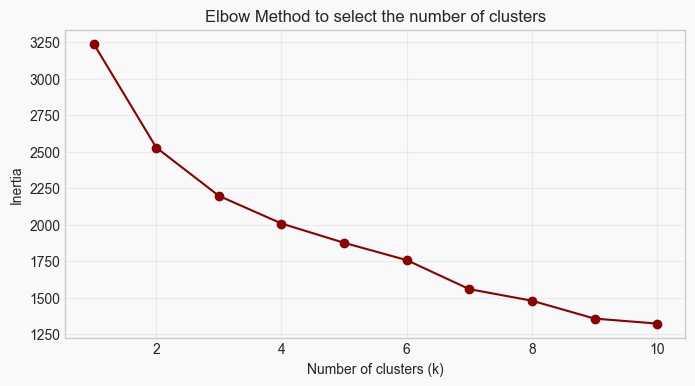

In [213]:
inertia = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, 'o-', color='darkred')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method to select the number of clusters")
plt.grid(True)
plt.show()

In [214]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

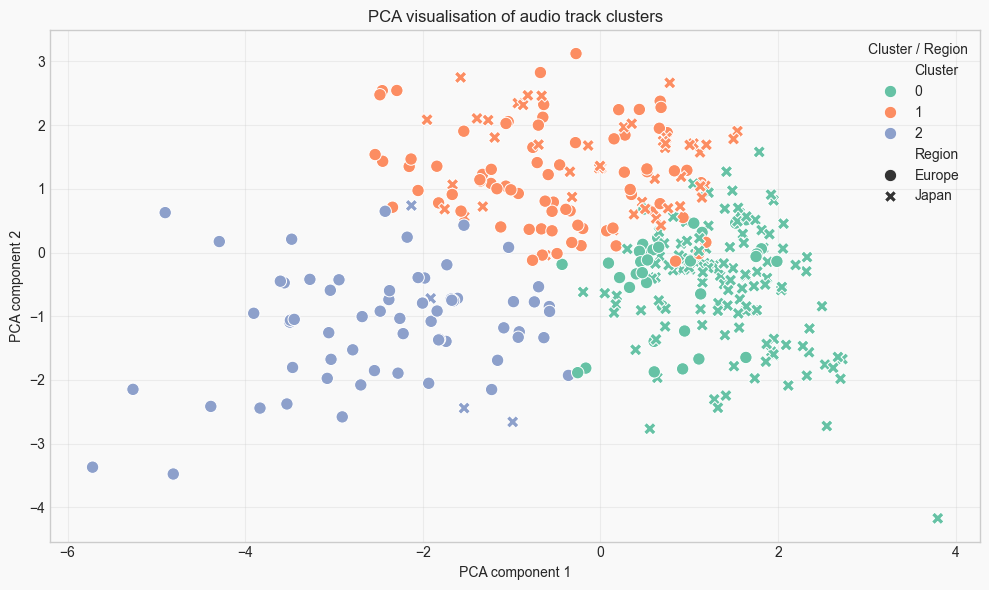

In [215]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='Cluster', palette='Set2', style='Region', s=80)
plt.title("PCA visualisation of audio track clusters")
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.legend(title="Cluster / Region")
plt.grid(True)
plt.tight_layout()
plt.show()

#### **🎧 Cluster Audio Profile Summary**

Based on the **average values** of audio features for each cluster, we can draw the following insights:

---

##### **Cluster 0**

* Displays the **highest levels of Energy (0.91)** and **Loudness (0.76)**.
* Very low **Acousticness (0.02)** suggests a strong emphasis on electronic instrumentation.
* A **high Tempo (142.56)** implies fast-paced music.
* According to earlier analysis, this cluster **corresponds to Japanese rock**, known for its elevated Energy, Loudness, and Tempo characteristics.

---

##### **Cluster 1**

* Has high values for **Danceability (0.62)** and **Valence (0.69)**, suggesting music that is more upbeat and danceable.
* Moderate levels of **Energy (0.75)** and **Loudness (0.61)**.
* Represents a **mixture of European and Japanese tracks**, making it a sort of universal style cluster that blends features from both regions.

---

##### **Cluster 2**

* Shows the **lowest Energy (0.44)** and **Loudness (0.37)** levels, indicating calmer rock music — possibly ballads.
* The **highest Acousticness (0.30)** suggests more frequent use of acoustic instruments.
* **Instrumentalness (0.14)** is also highest here, pointing to more instrumental sections or fully instrumental tracks.
* This cluster consists of **94% European songs**, reflecting a **classic, softer European rock style**.

---

### Conclusion

There are **notable stylistic differences** between the clusters, especially when it comes to energy and Loudness. These differences can be effectively used to build a **classification model**. European rock appears more subdued and acoustic in Cluster 2, whereas Japanese rock dominates the louder, more energetic Cluster 0.


In [216]:
pd.crosstab(df['Cluster'], df['Region'], normalize='index')

Region,Europe,Japan
Cluster,,
0,0.231707,0.768293
1,0.606299,0.393701
2,0.942029,0.057971


In [217]:
cluster_means = df.groupby('Cluster')[features].mean().round(2)
cluster_means

,Acousticness,Danceability,Energy,Valence,Instrumentalness,Speechiness,Liveness,Loudness (scaled),Tempo
Cluster,,,,,,,,,
0,0.02,0.43,0.91,0.48,0.02,0.10,0.25,0.76,142.56
1,0.20,0.62,0.75,0.69,0.03,0.06,0.16,0.61,114.71
2,0.30,0.42,0.44,0.27,0.14,0.04,0.17,0.37,114.56


In [218]:
popular_genres = df.groupby('Cluster')['Genre'].agg(lambda x: x.value_counts().idxmax())
popular_genres_df = popular_genres.reset_index()
popular_genres_df.columns = ['Cluster', 'Most Common Genre']

popular_genres_df

,Cluster,Most Common Genre
0,0,anime
1,1,classic rock
2,2,art rock


# **Classification**

#### 🎯 **Classification**

##### **Purpose of the classification**

The main purpose of the classification is to determine whether the audio characteristics of a song can be used to predict its region of origin: **Europe** or **Japan**. This allows us to check whether these styles are really different from the point of view of machine analysis.

---

##### **Model and approach**

For modelling, we used **XGBoost Classifier**, a powerful gradient boosting algorithm that works well with tabular data. The selected features cover both basic song metrics (duration, popularity) and audio characteristics, as well as data on musical structure.

The training and test samples were split 80/20, with the proportion of classes (stratify) preserved to avoid bias in the test part.

---

##### **Interpretation of results**

The model showed **excellent classification results**, which means that there are clear stylistic differences between Japanese and European rock that can be easily detected by automated algorithms. Most interestingly, while maintaining the balance of classes, the model demonstrates high **accuracy for both Japanese and European tracks**, meaning that the features not only explain the classes well, but are also not biased.

The mixing matrix showed that the model practically does not confuse regions: only 4 errors out of 72 songs. This suggests that although the styles may have some similarities (as seen in the clustering), the differences are sufficiently pronounced for the classifier to ‘pick up’ them.

---

##### **Insights from the importance of features**

One of the most important findings is that Loudness is the strongest predictor in the model. This is consistent with a previous analytical observation: **Japanese tracks are statistically significantly louder**, which may be due to a different approach to mastering or genre specificity (e.g., anime opening music should be more ‘expressive’).

The **popularity** of the track also makes a high contribution to the classification. This is logical, as European rock often has a wider audience and a better presence on global streaming services, making it more ‘universal’ in Spotify data. Tempo is another feature that plays an important role, which is also confirmed by the analysis: **Japanese rock has a more variable and often faster tempo**.

Features such as **danceability, energy, instrumentality** have a much lower weight. This may be explained by the fact that these characteristics are less specific to regional divisions and more dependent on the subgenre.

---

##### **✅ Conclusion**

The model not only copes well with the classification task, but also allows us to identify important **stylistic markers** of rock music from different regions. In particular:

* **Loudness and tempo** are among the main features that distinguish Japanese rock from European rock.
* Popularity plays a socio-cultural role in the classification, reflecting accessibility and audience reach.
* The model confirms the ideas identified in the clustering: **Japanese rock has its own style**, different from European rock, although there is some overlap between them.

Thus, the classification confirms the hypothesis of **regional specificity in the sound characteristics of rock** and opens the way to the development of recommendation systems or music research based on regional characteristics.

In [219]:
features = [
    'Popularity', 'Duration', 'Acousticness', 'Danceability', 'Energy',
    'Instrumentalness', 'Liveness', 'Loudness', 'Speechiness', 'Tempo', 'Valence'
]

In [220]:
le = LabelEncoder()
df['Region_encoded'] = le.fit_transform(df['Region'])  # Japan = 1, Europe = 0

In [221]:
X = df[features]
y = df['Region_encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [222]:
model = XGBClassifier(eval_metric='logloss', random_state=42)
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [223]:
y_pred = model.predict(X_test)

In [224]:
joblib.dump(model, '../models/region_classifier_model.pkl')
joblib.dump(le, '../models/region_label_encoder.pkl')

['../models/region_label_encoder.pkl']

In [225]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Classification Report:
              precision    recall  f1-score   support

      Europe       0.92      0.97      0.95        36
       Japan       0.97      0.92      0.94        36

    accuracy                           0.94        72
   macro avg       0.95      0.94      0.94        72
weighted avg       0.95      0.94      0.94        72



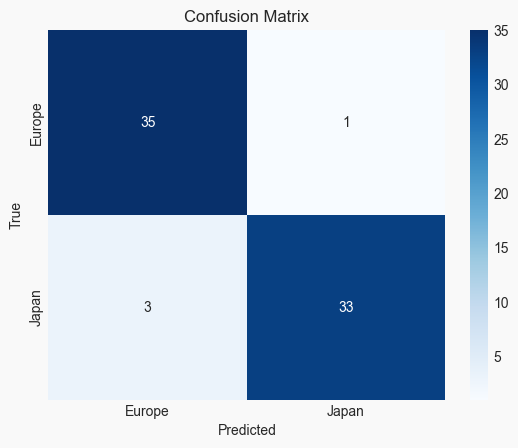

In [226]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

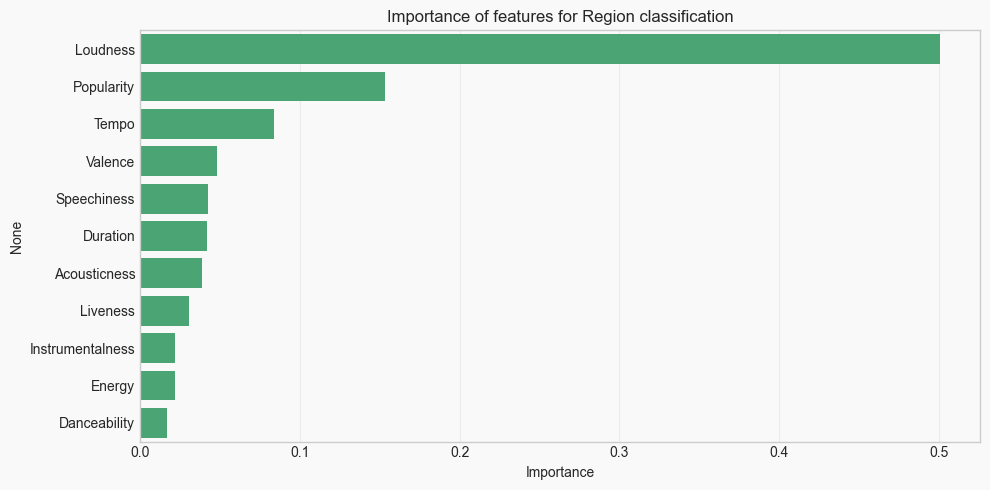

In [ ]:
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(10,5))
sns.barplot(x=importances.values, y=importances.index, color='mediumseagreen')
plt.title("Importance of features for Region classification")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

#### **An example of model testing**

(The script for using the classification model can be found at "*../src/classification model/user_predict.py*")

| Region | Artist name    | Track name                           | Genre        | Popularity | Duration | Acousticness | Danceability | Energy | Instrumentalness | Liveness | Loudness | Speechiness | Tempo   | Valence |
| ------ | -------------- | ------------------------------------ | ------------ | ---------- | -------- | ------------ | ------------ | ------ | ---------------- | -------- | -------- | ----------- | ------- | ------- |
| Japan  | YOASOBI        | 三原色                                  | j-pop        | 57.0       | 220253   | 0.0836       | 0.666        | 0.923  | 0.0              | 0.315    | -2.362   | 0.0712      | 128.014 | 0.861   |
| Japan  | LiSA           | Rising Hope                          | anime        | 50.0       | 253213   | 0.0659       | 0.515        | 0.976  | 0.0              | 0.0707   | -2.741   | 0.386       | 189.92  | 0.639   |
| Japan  | KANA-BOON      | ストラテジー                               | anime        | 38.0       | 244920   | 0.0032       | 0.251        | 0.925  | 0.0381           | 0.0621   | -3.366   | 0.105       | 162.623 | 0.331   |
| Europe | Deep Purple    | You Fool No One                      | hard rock    | 25.0       | 287693   | 0.00454      | 0.474        | 0.887  | 0.000466         | 0.191    | -6.07    | 0.0527      | 134.359 | 0.791   |
| Europe | Arctic Monkeys | Suck It and See                      | indie        | 51.0       | 225987   | 0.00105      | 0.339        | 0.932  | 0.114            | 0.255    | -5.017   | 0.057       | 128.291 | 0.586   |
| Europe | Queen          | Seaside Rendezvous - Remastered 2011 | classic rock | 49.0       | 134133   | 0.408        | 0.45         | 0.706  | 0.0              | 0.292    | -5.462   | 0.113       | 167.906 | 0.764   |

**Results:**

* KANA-BOON – ストラテジー:  
  - Forecasted region: Japan  
    - Probability for Europe: 0.00 (0.4%)  
    - Probability for Japan: 1.00 (99.6%)

* Arctic Monkeys – Suck It and See:
  - Forecasted region: Europe
    - Probability for Europe: 0.77 (77.0%)
    - Probability for Japan: 0.23 (23.0%)